In [1]:
import os
import sys
sys.path.append("../..")

import dill as pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.distributions as td
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as pyg
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.datasets import TUDataset

from egg_models import egg_generic_losses
from egg_models.egg_generic import EggGeneric
from egg_models.egg_generic import EggGeneric
from functools import partial
from matplotlib.patches import ConnectionPatch
from scipy.stats import gaussian_kde, t
from sklearn.metrics import confusion_matrix

from utils import mutag_helper
from utils import visuals
import pygmtools as pygm
import networkx as nx

from egg_models.egg_generic_losses import activation_hook, dict_cos_dist, GEDasMatchLoss
from scipy.stats import stats

/opt/miniconda/envs/egg-env-38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

#Meta-Data
device = torch.device(0)
node_types = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']
color_palette = np.array(['orange', 'magenta', 'green', 'blue', 'cyan', 'red', 'lime'])
color_palette_dropped = np.array(['orange', 'magenta', 'green', 'blue', 'red'])

# Data Prep

## Helper Functions

In [3]:
# Explainee Model
class GCN(torch.nn.Module):
    def __init__(self, node_features, hc1=64, hc2=32, hc3=16):
        super().__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(node_features, hc1)
        self.conv2 = GCNConv(hc1, hc2)
        self.conv3 = GCNConv(hc2, hc3)
        self.lin = nn.Linear(hc3, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x

In [4]:
def train_explainee(
    explainee: nn.Module,
    train_data: list, 
    test_data: list, 
    ):

    train_data_loader = pyg.loader.DataLoader(train_data, 
                                            batch_size=16, shuffle=True)
    test_data_loader = pyg.loader.DataLoader(test_data, 
                                            batch_size=16, shuffle=False)

    optimizer = torch.optim.Adam(explainee.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(201): 
        explainee.train()        
        for batch in train_data_loader: 
            out = explainee(batch)
            loss = criterion(out, batch.y)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

        explainee.eval()
        correct = 0
        for batch in train_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        train_accuracy = correct / len(train_data_loader.dataset)

        correct = 0
        for batch in test_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        test_accuracy = correct / len(test_data_loader.dataset)

        print(f"Epoch: {epoch} Train Accuracy: {train_accuracy} " + 
            f"Test Accuracy: {test_accuracy}")


    full_batch = pyg.data.Batch.from_data_list(test_data)
    explainee.eval()
    preds = explainee(full_batch).argmax(dim=1).numpy()
    targets = full_batch.y.numpy()

    conf_matrix = confusion_matrix(targets, preds)
    print(conf_matrix)

    return explainee

In [5]:
def extract_embeddings(
    explainee: nn.Module, 
    train_data: list, 
    ):

    activation_names = ["conv1", "conv2", "conv3"]
    train_avg_embedding_0 = {"conv1": [], "conv2": [], "conv3": []}
    train_avg_embedding_1 = {"conv1": [], "conv2": [], "conv3": []}
    pool_func = pyg.nn.global_mean_pool


    train_data_loader = pyg.loader.DataLoader(train_data)
    for batch in train_data_loader:
        explainee.eval()

        acts, remove_hooks = activation_hook(explainee, activation_names)
        out = explainee(batch)
        remove_hooks()

        if batch.y.item() == 0: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_0[name].append(
                    embed.detach().to('cpu')
                )

        if batch.y.item() == 1: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_1[name].append(
                    embed.detach().to('cpu')
                )
                
    for name in activation_names:
        train_avg_embedding_0[name] = torch.stack(
            train_avg_embedding_0[name]
        ).mean(dim=0)

        train_avg_embedding_1[name] = torch.stack(
            train_avg_embedding_1[name]
        ).mean(dim=0)

    return train_avg_embedding_0, train_avg_embedding_1

## Raw Data

In [6]:
# Raw data

# Download data. 
data_raw = TUDataset(root='data/TUDataset', name='MUTAG')

# Shuffle
data_raw = data_raw.shuffle()

# Split 
train_data = data_raw[:150]
test_data = data_raw[150:]

# Create data lists
train_data_list = []
train_data_list_0 = []
train_data_list_1 = []
test_data_list = []
test_data_list_0 = []
test_data_list_1 = []

for graph in train_data:
    train_data_list.append(graph)

    if graph.y.item() == 0: 
        train_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_1.append(graph)

for graph in test_data:
    test_data_list.append(graph)

    if graph.y.item() == 0: 
        test_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_1.append(graph)

In [7]:
explainee_raw = train_explainee(
    GCN(node_features=7), 
    train_data_list, test_data_list
)

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [8]:
train_avg_embedding_0, train_avg_embedding_1 = extract_embeddings(
    explainee_raw, train_data_list
)
print(train_avg_embedding_0)
print(train_avg_embedding_1)

{'conv1': tensor([[-2.4414e-02,  1.8963e-04,  1.6406e-02, -6.2468e-02,  1.1383e-01,
         -5.5692e-02,  1.4817e-01, -6.1993e-02,  3.1283e-01,  8.2443e-03,
         -1.6015e-01,  7.9258e-02,  2.1296e-03, -8.6245e-02, -1.9665e-01,
         -3.2812e-03, -2.5154e-02,  3.2330e-03, -1.2894e-04, -1.6158e-01,
         -3.3215e-02,  1.1894e-01,  7.1813e-02, -1.4019e-01,  1.9445e-02,
          2.1891e-02, -6.1676e-02,  1.6293e-01, -3.3140e-01,  1.7148e-01,
         -5.8332e-02, -1.1589e-01,  9.5046e-04, -1.3022e-01,  6.0876e-02,
         -3.9918e-02, -7.7869e-02,  5.1078e-02, -9.9482e-04,  1.4482e-01,
         -6.6134e-02,  1.6898e-02,  4.6021e-02, -3.1147e-02, -4.5866e-02,
         -1.2761e-01, -1.2067e-01,  6.3569e-02, -7.6452e-03,  1.3926e-03,
          1.2551e-02,  8.3930e-02, -2.4583e-02, -1.7069e-01,  1.3442e-02,
          2.9155e-02, -8.5881e-02,  3.0223e-03, -6.4913e-02, -2.2758e-04,
         -3.1409e-02,  7.6412e-03,  1.1536e-01, -9.7788e-02]]), 'conv2': tensor([[-0.0575, -0.0469,  0

## Dropped

In [9]:
data_dropped = []

for graph in data_raw:
    node_types = graph.x.argmax(dim=-1)
    edge_types = graph.edge_attr.argmax(dim=-1)

    if torch.any(node_types == 4) or torch.any(node_types == 6) or torch.any(edge_types == 3): 
        print(graph) 
    else: 
        graph.x = torch.cat([graph.x[:, :4], graph.x[:, 5].unsqueeze(1)], dim=1)
        graph.edge_attr = graph.edge_attr[:, :3]
        data_dropped.append(graph)

data_dropped[1]

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 28], x=[14, 7], edge_attr=[28, 4], y=[1])
Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 40], x=[18, 7], edge_attr=[40, 4], y=[1])


Data(edge_index=[2, 38], x=[17, 5], edge_attr=[38, 3], y=[1])

In [10]:
# Split 
train_data_dropped = data_dropped[:150]
test_data_dropped = data_dropped[150:]

# Create data lists
train_data_list_dropped = []
train_data_list_dropped_0 = []
train_data_list_dropped_1 = []
test_data_list_dropped = []
test_data_list_dropped_0 = []
test_data_list_dropped_1 = []

for graph in train_data_dropped:
    train_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        train_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_dropped_1.append(graph)

for graph in test_data_dropped:
    test_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        test_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_dropped_1.append(graph)

In [11]:
explainee_dropped = train_explainee(
    GCN(node_features=5), 
    train_data_list_dropped, 
    test_data_list_dropped
)  

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [12]:
train_avg_embedding_0_dropped, train_avg_embedding_1_dropped = extract_embeddings(
    explainee_dropped, train_data_list_dropped
)
print(train_avg_embedding_0_dropped)
print(train_avg_embedding_1_dropped)

{'conv1': tensor([[-0.0255,  0.1250,  0.1851,  0.1884, -0.0072,  0.1248,  0.0226,  0.1809,
          0.1125, -0.0764, -0.0685, -0.0043, -0.0304, -0.0095,  0.0238,  0.0168,
          0.0425,  0.0455, -0.0464,  0.0159, -0.1923, -0.0194,  0.1060,  0.0042,
         -0.0187, -0.0100,  0.1574,  0.0600, -0.0049,  0.0149,  0.0264,  0.1324,
          0.0132,  0.0643,  0.1187, -0.0107, -0.0045,  0.0320, -0.0315,  0.0227,
         -0.0813, -0.0081,  0.0973, -0.1581, -0.0052, -0.2818,  0.1156,  0.0103,
          0.1555,  0.0642, -0.0093,  0.0160,  0.0623,  0.1068, -0.0299,  0.1723,
         -0.0091,  0.1418,  0.0137,  0.0653,  0.1781, -0.0169,  0.0503,  0.0912]]), 'conv2': tensor([[-0.1955,  0.1653,  0.1867, -0.1174,  0.2490,  0.1667,  0.2741,  0.2149,
         -0.0471,  0.0788, -0.2016, -0.2270,  0.1708, -0.2745, -0.2861, -0.3021,
         -0.2619, -0.1897, -0.0645, -0.2028, -0.1541,  0.1281,  0.1435, -0.0651,
          0.1663,  0.2404,  0.0007, -0.1311, -0.1665, -0.1529,  0.0491,  0.1774]]), 'co

# EGG

## Helper Functions

In [9]:
def t_confidence_interval(data):
    mean = np.mean(data)
    std_dev = np.std(data)

    print(f"Mean {mean} SD: {std_dev}")

    n = len(data)
    t_value = t.ppf(0.975, df=n-1) 
    margin_of_error = t_value * (std_dev / np.sqrt(n))
    lower_bound = np.round(mean - margin_of_error, 4)
    upper_bound = np.round(mean + margin_of_error, 4)

    print(f"({lower_bound}, {upper_bound})")

In [10]:
def pre_acc_interval(
    generator: nn.Module, 
    explainee: nn.Module, 
    target
    ):
    generator.eval()
    explainee.eval()

    pred_acc = []
    for i in range(1000):
        with torch.no_grad():
            gen_ex = mutag_helper.egg_to_ex(generator())
            pred = torch.softmax(explainee(gen_ex), dim=-1).mean(dim=0)
            pred_acc.append(pred[target].item())
    
    t_confidence_interval(pred_acc)

In [11]:
def GED_interval(
    generator: nn.Module, 
    GED_fn: nn.Module, 
    data_list: list, 
    batch_size=16, 
    ):
    generator.eval()
    loader = pyg.loader.DataLoader(data_list, 
                                   batch_size=batch_size, drop_last=True)
    running_GED = []
    for batch in loader:
        batch = batch.to(device)
        with torch.no_grad():
            generated = generator()
            gen_ex = mutag_helper.egg_to_ex(generated)
            gen_egg = mutag_helper.egg_to_egg(generated)
            obs_egg = mutag_helper.ex_to_egg(batch)

            egg_sizes = torch.tensor([
                graph.x.shape[0] + graph.edge_index.shape[1] 
                for graph in gen_ex.to_data_list()
            ]).to(device)

            loss = (
                GED_fn(*gen_egg, *obs_egg) / 
                egg_sizes
            ).mean()

            running_GED.append(min(loss.item(), 1.0))

    t_confidence_interval(running_GED)

In [12]:
def train_egg(
    dis_node_feats: int, 
    dis_edge_feats: int, 
    explainee: nn.Module, 
    target: int, 
    train_data_list_1, 
    train_data_list_0, 
    train_data_list_full, 
    pred_loss_embeds, 
    other_class_embeds,  
    max_node_size=20, 
    temp=0.15, 
    epochs=25, 
    loss_fn_weights=torch.tensor([1.0, 1.0, 1.0, 1.0]), 
    use_egg_size=False, 
    use_omega=True,  
    batch_size=16
    ):
    # Define target tensors. 
    if target == 1:
        target_tensor = torch.tensor([0.0, 1.0])
    else: 
        target_tensor = torch.tensor([1.0, 0.0])

    # Setup explainee. 
    explainee.eval()
    explainee.to(device)

    # Define generator to train. 
    generator = EggGeneric(
        max_node_size=max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=temp, 
        batch_size=batch_size, 
    )
    generator.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    # Compute random baseline.
    print("Baseline Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Baseline % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Baseline % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    # Train EGG model.
    train_loader = pyg.loader.DataLoader(train_data_list_full, 
                                         batch_size=batch_size, drop_last=True)
    pred_loss_fn = egg_generic_losses.PredLossBatched(
        target_tensor, explainee, avg_embed_targets=pred_loss_embeds
    )
    embed_dist_fn = egg_generic_losses.EmbDistGeneric(
        explainee, avg_embed_targets=other_class_embeds
    )
    edge_pen_fn = egg_generic_losses.EdgePenalty(edge_budget = 10)
    generator.train()
    optimizer = torch.optim.RMSprop(generator.parameters()) 
    for epoch in range(epochs):
        report_loss = np.array([0.0, 0.0, 0.0, 0.0])
        for obs_batch in train_loader: 
            optimizer.zero_grad()
            obs_batch = obs_batch.to(device)
            gen_graph = generator()

            # Data formatting. 
            gen_ex = mutag_helper.egg_to_ex(gen_graph) 
            gen_egg = mutag_helper.egg_to_egg(gen_graph)
            obs_egg = mutag_helper.ex_to_egg(obs_batch)

            loss_1, _, _ = pred_loss_fn(gen_ex)
            loss_1 = loss_1.mean()

            loss_embed = -1 * embed_dist_fn(gen_ex).mean()

            #loss_edge = torch.sum(generator.AdjacencyMatrix.probs, dim=0).mean()
            loss_edge = edge_pen_fn(generator.AdjacencyMatrix.probs)

            loss_2 = GED_fn(*gen_egg, *obs_egg)
            if use_egg_size:
                egg_size = torch.tensor([
                    graph.x.shape[0] + graph.edge_index.shape[1] 
                    for graph in gen_ex.to_data_list()
                ]).to(loss_2.device)
            else: 
                egg_size = 1.0
            
            if use_omega:
                with torch.no_grad():
                    explainee_pred = F.softmax(explainee(obs_batch), dim=-1)
                    omega = (explainee_pred @ 
                        target_tensor.to(explainee_pred.device) - 0.5
                    )
            else:
                omega = 1
            loss_3 = (omega * loss_2 / egg_size).mean()

            report_loss += [loss_1.item(), loss_embed.item(), 
                            loss_edge.item(), loss_3.item()]
            report_loss
            loss = (
                loss_fn_weights.to(loss_1.device) @ 
                torch.stack((loss_1, loss_embed, loss_edge, loss_3)) 
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)

            optimizer.step() 

        report_loss = [x / len(train_loader) for x in report_loss]
        print(f"Epoch: {epoch} Losses:{report_loss}")

    print("Trained Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Trained % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Trained % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    return generator 

In [13]:
def edge_replace(gen_egg, gen_ex, obs_egg, obs_ex, GED_fn):

    graph_1 = gen_ex
    graph_2 = obs_ex
    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg)
        matching_matrix = GED_fn.get_dis_match_mat(aff_mat)
    
    # Extract edge information from graph_2
    edge_index_2 = graph_2.edge_index  # shape [2, num_edges]
    edge_attr_2 = graph_2.edge_attr if hasattr(graph_2, "edge_attr") else None  # Optional attribute

    # Initialize new edge lists for graph_1
    new_edge_index = []
    new_edge_attr = []

    # Iterate over the edges in graph_2
    for edge_idx in range(edge_index_2.size(1)):
        src, tgt = edge_index_2[:, edge_idx]  # Source and target node indices in graph_2

        # Check if this edge matches the nodes in graph_1 based on the matching matrix
        if matching_matrix[0, :, src].any() and matching_matrix[0, :, tgt].any():
            # Find corresponding nodes in graph_1
            src_1 = torch.where(matching_matrix[0, :, src])[0].item()
            tgt_1 = torch.where(matching_matrix[0, :, tgt])[0].item()

            # Append the new edge and its attributes
            new_edge_index.append([src_1, tgt_1])
            if edge_attr_2 is not None:
                new_edge_attr.append(edge_attr_2[edge_idx])

    # Convert to tensor format
    new_edge_index = torch.tensor(new_edge_index).t().contiguous() if new_edge_index else torch.empty((2, 0), dtype=torch.long)
    if new_edge_attr:
        new_edge_attr = torch.stack(new_edge_attr)
    else:
        new_edge_attr = None

    # Update and return the modified graph_1
    graph_1.edge_index = new_edge_index
    graph_1.edge_attr = new_edge_attr
    
    return graph_1


In [14]:
def edge_reduce(gen_egg, gen_ex, obs_egg, obs_ex, GED_fn):

    graph_1 = gen_ex
    graph_2 = obs_ex
    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg)
        matching_matrix = GED_fn.get_dis_match_mat(aff_mat)

    # Extract edge information from graph_2
    edge_index_2 = graph_2.edge_index  # shape [2, num_edges]
    
    # Build a set of valid edges in graph_2 using matching_matrix
    valid_edges = set()
    for edge_idx in range(edge_index_2.size(1)):
        src_2, tgt_2 = edge_index_2[:, edge_idx]
        src_1_candidates = torch.where(matching_matrix[0, :, src_2])[0]
        tgt_1_candidates = torch.where(matching_matrix[0, :, tgt_2])[0]
        for src_1 in src_1_candidates:
            for tgt_1 in tgt_1_candidates:
                valid_edges.add((src_1.item(), tgt_1.item()))
                valid_edges.add((tgt_1.item(), src_1.item()))  # Add both directions for undirected graphs

    # Filter edges in graph_1
    reduced_edge_index = []
    reduced_edge_attr = []
    for edge_idx in range(graph_1.edge_index.size(1)):
        src_1, tgt_1 = graph_1.edge_index[:, edge_idx]
        if (src_1.item(), tgt_1.item()) in valid_edges:
            reduced_edge_index.append([src_1.item(), tgt_1.item()])
            if graph_1.edge_attr is not None:
                reduced_edge_attr.append(graph_1.edge_attr[edge_idx])

    # Convert to tensor format
    reduced_edge_index = torch.tensor(reduced_edge_index).t().contiguous() if reduced_edge_index else torch.empty((2, 0), dtype=torch.long)
    if reduced_edge_attr:
        reduced_edge_attr = torch.stack(reduced_edge_attr)
    else:
        reduced_edge_attr = None

    # Update and return the reduced graph_1
    graph_1.edge_index = reduced_edge_index
    graph_1.edge_attr = reduced_edge_attr
    return pyg.data.Batch().from_data_list([graph_1])

In [15]:
# Visualize Connected Graph
def vis_con_graph(
    generator: nn.Module, 
    explainee: nn.Module, 
    dis_node_feats: int, 
    dis_edge_feats: int, 
    target: int, 
    obs_ex1, 
    obs_ex2, 
    color_palette=color_palette
    ):

    generator_batch_1 = EggGeneric(
        max_node_size=generator.max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=generator.temp, 
        batch_size=1, 
    )
    generator_batch_1.load_state_dict(generator.state_dict())
    generator_batch_1.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=generator.max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    gen = generator_batch_1()
    gen_ex = mutag_helper.egg_to_ex(gen)
    gen_egg = mutag_helper.egg_to_egg(gen)
    colors0 = color_palette[torch.argmax(gen_ex.x, dim=-1).cpu().numpy()]
    gen_nx = pyg.utils.to_networkx(gen_ex)

    obs_ex1 = obs_ex1.to(device)
    obs_egg1 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex1]))
    colors1 = color_palette[torch.argmax(obs_ex1.x, dim=-1).cpu().numpy()]
    obs_nx = pyg.utils.to_networkx(obs_ex1)

    obs_ex2 = obs_ex2.to(device)
    obs_egg2 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex2]))
    colors2 = color_palette[torch.argmax(obs_ex2.x, dim=-1).cpu().numpy()]
    obs_nx2 = pyg.utils.to_networkx(obs_ex2)
    
    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg1)
        dis_match_mat = GED_fn.get_dis_match_mat(aff_mat)

    with torch.no_grad():
        aff_mat2 = GED_fn.get_aff_mat(*gen_egg, *obs_egg2)
        dis_match_mat2 = GED_fn.get_dis_match_mat(aff_mat2)

    egg_size = torch.tensor([
        graph.x.shape[0] + graph.edge_index.shape[1] 
        for graph in gen_ex.to_data_list()
    ]).to(device)

    GED_score1 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat, aff_mat) / 
        egg_size
    ).item()
    GED_score1 = min(GED_score1, 1.0) # cap at 100% edit.

    GED_score2 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat2, aff_mat2) / 
        egg_size
    ).item()
    GED_score2 = min(GED_score2, 1.0)


    # pos_1 = nx.spring_layout(obs_nx)
    pos_1 = nx.kamada_kawai_layout(obs_nx)
    # pos_2 = nx.spring_layout(gen_nx)
    #pos_2 = nx.kamada_kawai_layout(gen_nx)
    pos_2 = {}
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        pos_2[i] = pos_1[j]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    nx.draw(obs_nx, node_color=colors1, pos=pos_1, ax=axes[0], arrows=False)

    nx.draw(gen_nx, node_color=colors0, pos=pos_2, ax=axes[1], arrows=False)

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_1[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[1], axesB=axes[0], color="green")

        fig.add_artist(con)

    # pos_3 = nx.spring_layout(obs_nx2)
    pos_3 = nx.kamada_kawai_layout(obs_nx2)
    # pos_3 = {}
    # for i in range(gen_ex.x.shape[0]):
        # j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        # pos_3[j] = pos_2[i]

    nx.draw(obs_nx2, node_color=colors2, pos=pos_3, ax=axes[2], arrows=False)

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_3[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[2], axesB=axes[1], color="blue")

        fig.add_artist(con)

    explainee.eval()
    with torch.no_grad():
        pred_gen = torch.softmax(explainee(gen_ex), -1)[:, target].item()
        pred_obs1 = torch.softmax(explainee(obs_ex1), -1)[:, target].item()
        pred_obs2 = torch.softmax(explainee(obs_ex2), -1)[:, target].item()

    axes[0].set_title(f"Class Probability: {pred_obs1:0.2f} GED: {GED_score1:0.2f}")
    axes[1].set_title(f"Class Probability: {pred_gen:0.2f}")
    axes[2].set_title(f"GED: {GED_score2:0.2f} Class Probability: {pred_obs2:0.2f}")

In [92]:
def vis_con_graph_replace(
    generator: nn.Module, 
    explainee: nn.Module, 
    dis_node_feats: int, 
    dis_edge_feats: int, 
    target: int, 
    obs_ex1, 
    obs_ex2, 
    color_palette=color_palette
    ):

    generator_batch_1 = EggGeneric(
        max_node_size=generator.max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=generator.temp, 
        batch_size=1, 
    )
    generator_batch_1.load_state_dict(generator.state_dict())
    generator_batch_1.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=generator.max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    gen = generator_batch_1()
    gen_ex = mutag_helper.egg_to_ex(gen)
    gen_egg = mutag_helper.egg_to_egg(gen)
    
    obs_ex1 = obs_ex1.to(device)
    obs_egg1 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex1]))
    
    obs_ex2 = obs_ex2.to(device)
    obs_egg2 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex2]))
    
    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg1)
        dis_match_mat = GED_fn.get_dis_match_mat(aff_mat)

    with torch.no_grad():
        aff_mat2 = GED_fn.get_aff_mat(*gen_egg, *obs_egg2)
        dis_match_mat2 = GED_fn.get_dis_match_mat(aff_mat2)

    egg_size = torch.tensor([
        graph.x.shape[0] + graph.edge_index.shape[1] 
        for graph in gen_ex.to_data_list()
    ]).to(device)

    GED_score1 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat, aff_mat) / 
        egg_size
    ).item()
    GED_score1 = min(GED_score1, 1.0) # cap at 100% edit.

    GED_score2 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat2, aff_mat2) / 
        egg_size
    ).item()
    GED_score2 = min(GED_score2, 1.0)

    # Edge replacement
    #gen_ex = edge_replace(gen_egg, gen_ex, obs_egg1, obs_ex1, GED_fn)
    gen_ex = mutag_helper.clean_gen_graph(gen_ex)
    gen_ex = gen_ex.to(device)
    #gen_egg = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([gen_ex]))
    #gen_egg = mutag_helper.egg_to_egg(gen_egg)
    
    colors0 = color_palette[torch.argmax(gen_ex.x, dim=-1).cpu().numpy()]
    gen_nx = pyg.utils.to_networkx(gen_ex)

    colors1 = color_palette[torch.argmax(obs_ex1.x, dim=-1).cpu().numpy()]
    obs_nx = pyg.utils.to_networkx(obs_ex1)

    colors2 = color_palette[torch.argmax(obs_ex2.x, dim=-1).cpu().numpy()]
    obs_nx2 = pyg.utils.to_networkx(obs_ex2)
    
    # pos_1 = nx.spring_layout(obs_nx)
    pos_1 = nx.kamada_kawai_layout(obs_nx)
    # pos_2 = nx.spring_layout(gen_nx)
    pos_2 = nx.kamada_kawai_layout(gen_nx)
    #pos_2 = {}
    #for i in range(gen_ex.x.shape[0]):
    #    j = torch.argmax(dis_match_mat.squeeze()[i]).item()
    #   pos_2[i] = pos_1[j]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    nx.draw(obs_nx, node_color=colors1, pos=pos_1, ax=axes[0], arrows=False)

    nx.draw(gen_nx, node_color=colors0, pos=pos_2, ax=axes[1], arrows=False)

    # pos_3 = nx.spring_layout(obs_nx2)
    pos_3 = nx.kamada_kawai_layout(obs_nx2)
    #for i in range(gen_ex.x.shape[0]):
    #    j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
    #   pos_3[j] = pos_2[i]

    nx.draw(obs_nx2, node_color=colors2, pos=pos_3, ax=axes[2], arrows=False)
    
    explainee.eval()
    with torch.no_grad():
        pred_gen = torch.softmax(explainee(gen_ex), -1)[:, target].item()
        pred_obs1 = torch.softmax(explainee(obs_ex1), -1)[:, target].item()
        pred_obs2 = torch.softmax(explainee(obs_ex2), -1)[:, target].item()

    axes[0].set_title(f"Class Probability: {pred_obs1:0.2f} GED: {GED_score1:0.2f}")
    axes[1].set_title(f"Class Probability: {pred_gen:0.2f}")
    axes[2].set_title(f"GED: {GED_score2:0.2f} Class Probability: {pred_obs2:0.2f}")

# Results

## Re-implementationn of GNNInterpreter

In [14]:
gen_gnnInt_1 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.13140289115789347 SD: 0.06238653994422856
(0.1275, 0.1353)
Baseline % GED to 1




100%|██████████| 22.6k/22.6k [00:00<00:00, 4.90MB/s]
/opt/miniconda/envs/egg-env-38/lib/python3.10/site-packages/pygmtools/utils.py:1382: RuntimeWarning: coroutine '_asyncdownload' was never awaited
  return _download(filename, url, md5, retries - 1, to_cache)
/opt/miniconda/envs/egg-env-38/lib/python3.10/site-packages/pygmtools/pytorch_backend.py:1546: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializatio

Mean 0.08660684738840375 SD: 0.003116822379468773
(0.0837, 0.0895)
Baseline % GED to 0
Mean 0.07098818756639957 SD: 0.004559199003308718
(0.0662, 0.0758)
Epoch: 0 Losses:[1.954576080495661, -0.8059044832533057, 15551.007457386364, 2.7154695608399133]
Epoch: 1 Losses:[1.1258218667723916, -1.3674814050847834, 3903.9522816051135, 2.8269852995872498]
Epoch: 2 Losses:[0.7744893350384452, -1.619808467951688, 1067.6724465110085, 2.96013360673731]
Epoch: 3 Losses:[0.695440265265378, -1.671096303246238, 343.6255160245028, 3.0004883354360405]
Epoch: 4 Losses:[0.5809725197878751, -1.7530768242749302, 120.28131311590022, 2.9592014984651045]
Epoch: 5 Losses:[0.5537998893044211, -1.771407051519914, 45.251687656749375, 3.017881068316373]
Epoch: 6 Losses:[0.609010021794926, -1.740137674591758, 18.107525392012164, 2.9865813742984426]
Epoch: 7 Losses:[0.579832911491394, -1.7648390206423672, 8.112575444308193, 2.99730506810275]
Epoch: 8 Losses:[0.524578186598691, -1.8050828630273992, 4.445366295901212, 2

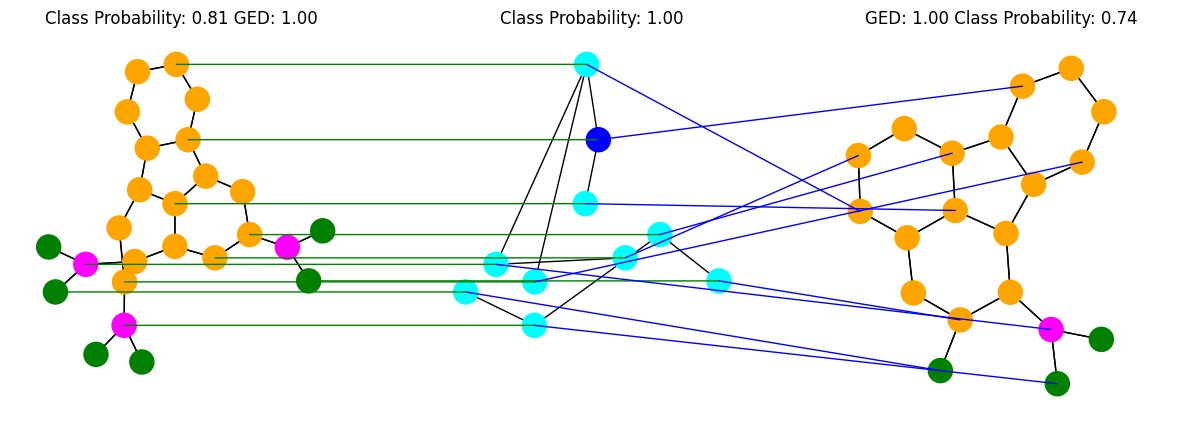

In [21]:
vis_con_graph(
    gen_gnnInt_1, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [20]:
gen_gnnInt_0 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.8938221929073333 SD: 0.06034374999959982
(0.8901, 0.8976)
Baseline % GED to 1
Mean 0.08497185579368047 SD: 0.0021748679959662652
(0.083, 0.087)
Baseline % GED to 0
Mean 0.06999372442563374 SD: 0.0047786468871842324
(0.065, 0.075)
Epoch: 0 Losses:[0.47081270001151343, -1.814669739116322, 12895.027654474432, -2.639627592130141]
Epoch: 1 Losses:[0.4337987168268724, -1.8380248654972424, 2090.967862215909, -2.7671232982115312]
Epoch: 2 Losses:[0.4524864202195948, -1.825787609273737, 674.8492098721591, -2.8648177656260403]
Epoch: 3 Losses:[0.4390550607984716, -1.830925627188249, 269.8680239590731, -2.931055264039473]
Epoch: 4 Losses:[0.4269930205561898, -1.8450009497729214, 113.69017306241122, -2.9599076942964033]
Epoch: 5 Losses:[0.411093378608877, -1.8520654114809902, 50.20970396562056, -2.911559386686845]
Epoch: 6 Losses:[0.38671213117512787, -1.8674685088070957, 23.62685047496449, -2.9325362660668115]
Epoch: 7 Losses:[0.4123392836614089, -1.848526347

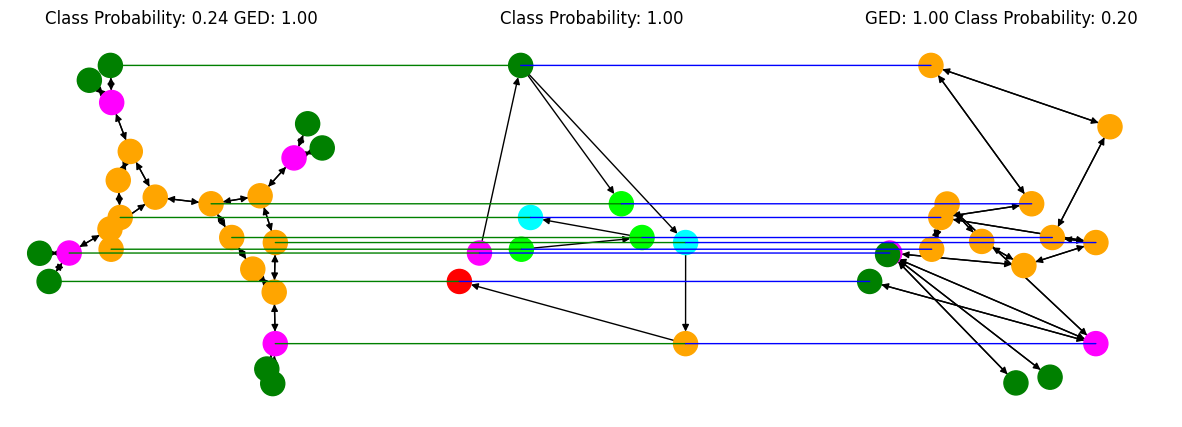

In [21]:
vis_con_graph(
    gen_gnnInt_0,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[2].clone(), 
    obs_ex2=test_data_list_0[3].clone(), 
    target=0
)

In [22]:
gen_gnnInt_1_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.014300748585315886 SD: 0.013163068925805325
(0.0135, 0.0151)
Baseline % GED to 1
Mean 0.08270553393023354 SD: 0.0018475150827538917
(0.081, 0.0844)
Baseline % GED to 0
Mean 0.06557025822500388 SD: 0.0038152099002639246
(0.0616, 0.0696)
Epoch: 0 Losses:[2.9850882183421743, -0.09807732836766676, 12797.25106534091, 2.669264793395996]
Epoch: 1 Losses:[2.881664687936956, -0.13198224929246036, 2100.522449840199, 2.799381998452273]
Epoch: 2 Losses:[2.960772752761841, -0.09017178822647441, 630.2878168279475, 2.8378397443077783]
Epoch: 3 Losses:[3.02592227675698, -0.07231052355332808, 232.17329961603338, 2.862061793153936]
Epoch: 4 Losses:[3.0551970438523726, -0.05775767124511979, 96.77943697842684, 2.886484991420399]
Epoch: 5 Losses:[3.0704333782196045, -0.05374088409272107, 42.2953596982089, 2.882672429084778]
Epoch: 6 Losses:[3.042697321284901, -0.07235118204897101, 19.510912201621316, 2.9472423033280806]
Epoch: 7 Losses:[3.0543515898964624, -0.061558643

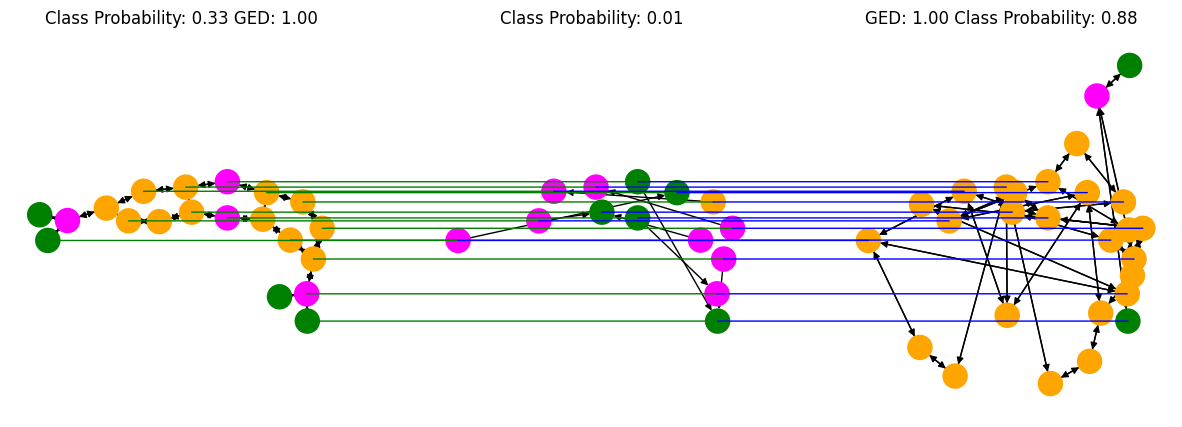

In [23]:
vis_con_graph(
    gen_gnnInt_1_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[1].clone(), 
    obs_ex2=test_data_list_dropped_1[5].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [24]:
gen_gnnInt_0_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9949280791878701 SD: 0.007510077878216179
(0.9945, 0.9954)
Baseline % GED to 1
Mean 0.07771138039728005 SD: 0.0023818024549212436
(0.0762, 0.0792)
Baseline % GED to 0
Mean 0.06808070341746013 SD: 0.0010423938474445724
(0.0655, 0.0707)
Epoch: 0 Losses:[0.3850688338279724, -1.8464823744513772, 11917.831853693182, -2.4489271315661343]
Epoch: 1 Losses:[0.3796396932818673, -1.848885796286843, 2024.5123512961648, -2.572062226859006]
Epoch: 2 Losses:[0.378971129655838, -1.8494518236680464, 654.2056857022372, -2.6269513693722812]
Epoch: 3 Losses:[0.37852148576216266, -1.849344177679582, 251.3163396661932, -2.697583415291526]
Epoch: 4 Losses:[0.3771200044588609, -1.846600434996865, 105.56866524436258, -2.5849286859685723]
Epoch: 5 Losses:[0.38462972099130804, -1.8373134569688276, 45.48205375671387, -2.608708842234178]
Epoch: 6 Losses:[0.37651030312884937, -1.8411682844161987, 20.465584234757856, -2.62367244200273]
Epoch: 7 Losses:[0.38397560065442865, -1.83

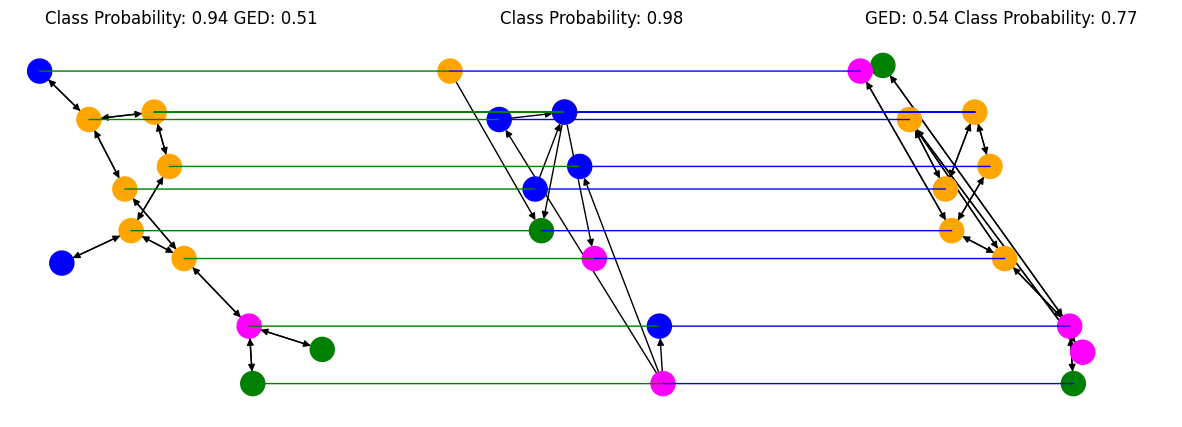

In [25]:
vis_con_graph(
    gen_gnnInt_0_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Multi-Layer Embedding Similarity

In [26]:
gen_gnnInt_1_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.028246546296140877 SD: 0.024777014911057986
(0.0267, 0.0298)
Baseline % GED to 1
Mean 0.08811754414013453 SD: 0.0026126725019708914
(0.0857, 0.0905)
Baseline % GED to 0
Mean 0.07218516121308009 SD: 0.005685924101151869
(0.0662, 0.0782)
Epoch: 0 Losses:[2.141791755502874, -0.24535919895226305, 11397.657115589489, 2.5741442116824063]
Epoch: 1 Losses:[1.5562863675030796, -0.8020325655286963, 1867.0102095170455, 2.6898140257055108]
Epoch: 2 Losses:[1.2634854858571833, -1.1361375505273992, 647.3759266246449, 2.7468794909390537]
Epoch: 3 Losses:[1.1881710941141301, -1.202466374093836, 243.69402105158025, 2.759486436843872]
Epoch: 4 Losses:[1.0707565058361401, -1.3732084469361738, 106.03903059525923, 2.794988892295144]
Epoch: 5 Losses:[0.9457718459042636, -1.5073889710686423, 46.57761625810103, 2.7163234678181736]
Epoch: 6 Losses:[0.9055999354882673, -1.5560664588754827, 20.84661899913441, 2.786048650741577]
Epoch: 7 Losses:[0.8536449345675382, -1.6194582

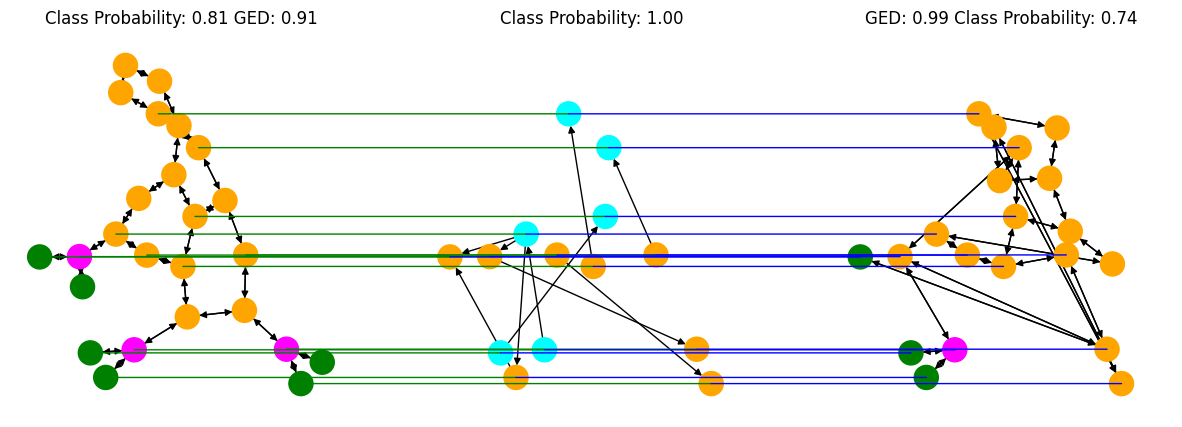

In [27]:
vis_con_graph(
    gen_gnnInt_1_ml, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [28]:
gen_gnnInt_0_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.8515324277281762 SD: 0.07247550230979835
(0.847, 0.856)
Baseline % GED to 1
Mean 0.08569860139063426 SD: 0.0030373503169608936
(0.0829, 0.0885)
Baseline % GED to 0
Mean 0.07102117997904618 SD: 0.00431702320379039
(0.0665, 0.0756)
Epoch: 0 Losses:[0.8298153931444342, -1.7254269556565718, 12304.745716441761, -2.6656428467143667]
Epoch: 1 Losses:[0.7199903238903392, -1.8377993648702449, 2024.8675315163352, -2.790467283942483]
Epoch: 2 Losses:[0.7053578983653676, -1.8342431675304065, 636.4301286177201, -2.7617395249280063]
Epoch: 3 Losses:[0.7173105857589028, -1.8023941408504138, 245.0344099564986, -2.8154239004308526]
Epoch: 4 Losses:[0.6767260974103754, -1.8282066041773015, 104.92473602294922, -2.7873569185083564]
Epoch: 5 Losses:[0.6639058319005099, -1.840314583344893, 47.40710241144354, -2.8132425113157793]
Epoch: 6 Losses:[0.6514412814920599, -1.8280026045712559, 22.748289108276367, -2.811878887089816]
Epoch: 7 Losses:[0.6777258515357971, -1.78617

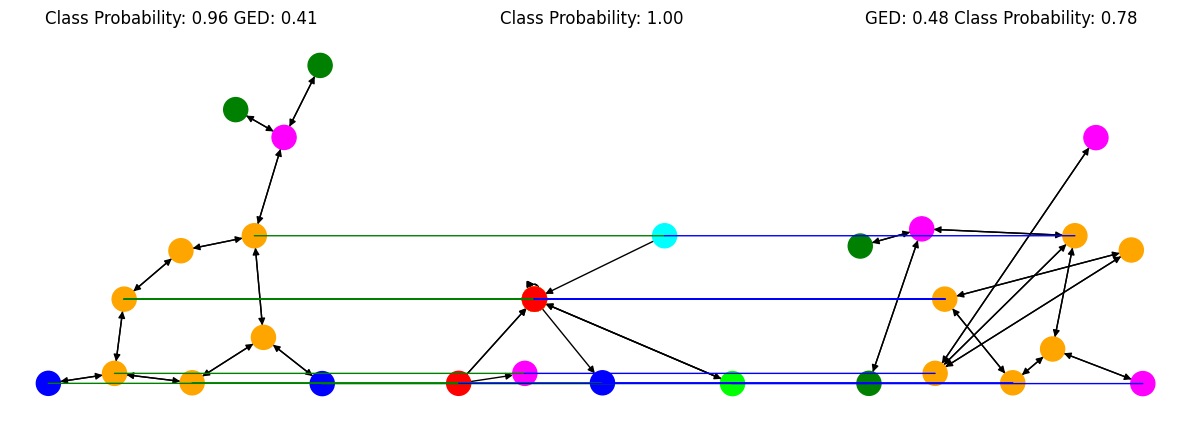

In [29]:
vis_con_graph(
    gen_gnnInt_0_ml,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [30]:
gen_gnnInt_1_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.0003220471345111946 SD: 0.0009787583757689079
(0.0003, 0.0004)
Baseline % GED to 1
Mean 0.08086358542953219 SD: 0.00362454335643942
(0.0775, 0.0842)
Baseline % GED to 0
Mean 0.06550237908959389 SD: 0.004677259150726959
(0.0606, 0.0704)
Epoch: 0 Losses:[2.3433113314888696, -0.06917999684810638, 12535.546209161932, 2.4295270172032444]
Epoch: 1 Losses:[2.1949737938967617, -0.06261935728517445, 2066.579012784091, 2.4271491982720117]
Epoch: 2 Losses:[1.9488083882765337, -0.10004049234769562, 643.779316295277, 2.2760904756459324]
Epoch: 3 Losses:[1.5411191636865789, -0.4124754856933247, 239.89865251020953, 2.2263564575802195]
Epoch: 4 Losses:[1.0887565666979009, -0.893605952913111, 99.62205089222302, 2.239716123450886]
Epoch: 5 Losses:[1.091832003810189, -0.8707634644074873, 43.47893853621049, 2.2011554674668745]
Epoch: 6 Losses:[0.8568225828084078, -1.1737939444455234, 20.2220817045732, 2.16750847751444]
Epoch: 7 Losses:[0.7785916165872053, -1.315569660

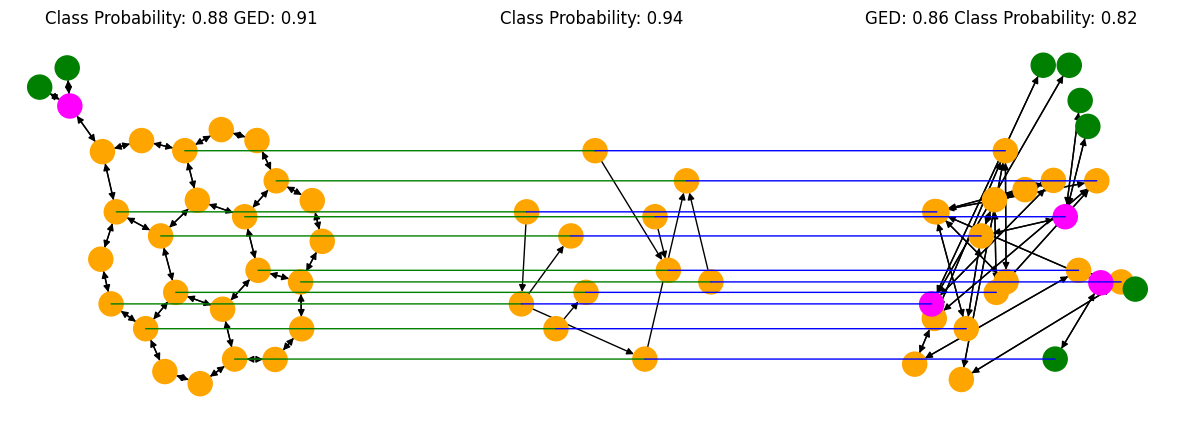

In [31]:
vis_con_graph(
    gen_gnnInt_1_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [32]:
gen_gnnInt_0_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9618632144927979 SD: 0.02490568458476401
(0.9603, 0.9634)
Baseline % GED to 1
Mean 0.07550291468699773 SD: 0.0020643582145773594
(0.0742, 0.0768)
Baseline % GED to 0
Mean 0.06602741032838821 SD: 0.001275770198663911
(0.0629, 0.0692)
Epoch: 0 Losses:[0.5611028833822771, -1.840351169759577, 11928.357044566761, -2.176341409032995]
Epoch: 1 Losses:[0.477924796667966, -1.8386907577514648, 1877.9445856267755, -2.1648762334476817]
Epoch: 2 Losses:[0.457909957929091, -1.7965325008739124, 582.0688726251775, -2.204637413675135]
Epoch: 3 Losses:[0.4736816070296548, -1.76344726302407, 217.63316761363637, -2.213161137971011]
Epoch: 4 Losses:[0.4712477055462924, -1.7681449543346057, 90.10934101451527, -2.249591285532171]
Epoch: 5 Losses:[0.4783774587241086, -1.7716530778191306, 39.855727282437414, -2.245249396020716]
Epoch: 6 Losses:[0.5064929534088481, -1.7266569571061567, 18.39830103787509, -2.2330743236975237]
Epoch: 7 Losses:[0.5009152916344729, -1.740436369

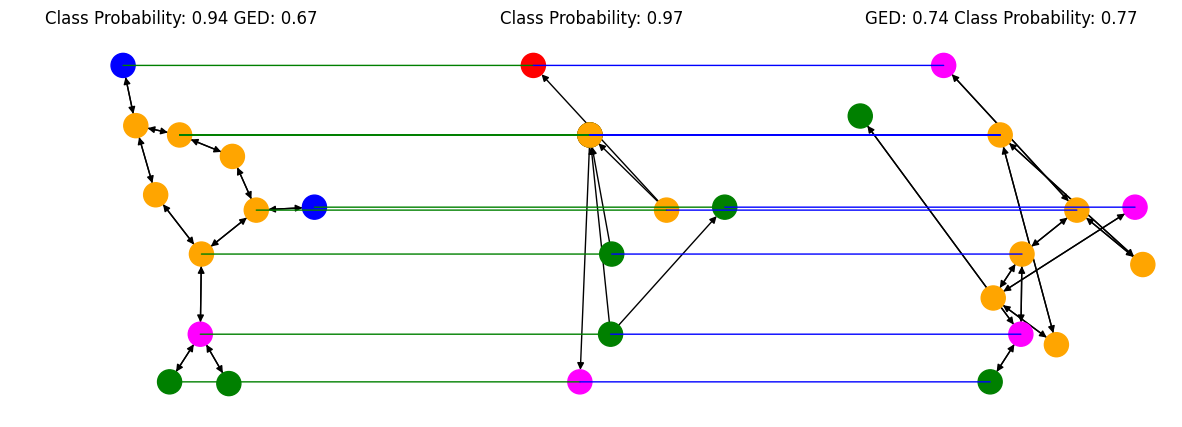

In [33]:
vis_con_graph(
    gen_gnnInt_0_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Opposing Class Embeddings

In [34]:
gen_gnnInt_1_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.06757076661870814 SD: 0.04366734959793485
(0.0649, 0.0703)
Baseline % GED to 1
Mean 0.09076541449342455 SD: 0.0029218241570736787
(0.0881, 0.0935)
Baseline % GED to 0
Mean 0.07463230689366658 SD: 0.0047057613327385886
(0.0697, 0.0796)
Epoch: 0 Losses:[1.917814547365362, -0.5155821388418024, 11228.15926846591, 2.6996402848850596]
Epoch: 1 Losses:[1.2935878363522617, -0.7843138412995772, 2406.69199440696, 2.8571749383753]
Epoch: 2 Losses:[1.1791934316808528, -0.8793384757908908, 852.3962235884233, 2.909899657422846]
Epoch: 3 Losses:[0.9633704152974215, -0.993251383304596, 313.38450622558594, 2.907521990212527]
Epoch: 4 Losses:[0.9542841802943837, -1.0056315064430237, 120.0884517322887, 2.9579833204096015]
Epoch: 5 Losses:[0.8667770732532848, -1.06328716061332, 49.54071183638139, 2.966369916092266]
Epoch: 6 Losses:[0.9019682082262906, -1.0618194450031628, 21.97415976090865, 3.0487075610594316]
Epoch: 7 Losses:[0.8787326541813937, -1.0815172574736855, 

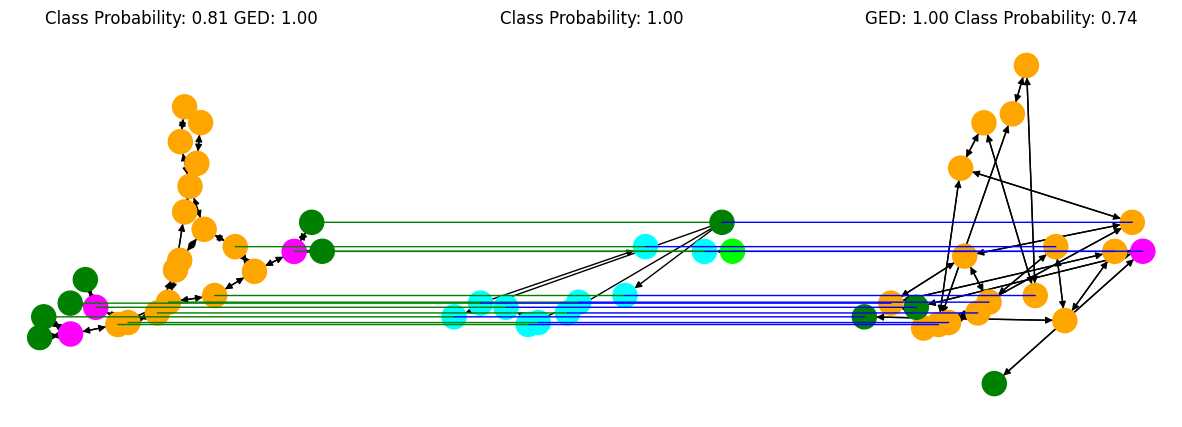

In [35]:
vis_con_graph(
    gen_gnnInt_1_oc, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [36]:
gen_gnnInt_0_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9454878773093224 SD: 0.03737478291317026
(0.9432, 0.9478)
Baseline % GED to 1
Mean 0.08038167655467987 SD: 0.0020021211488888274
(0.0785, 0.0822)
Baseline % GED to 0
Mean 0.06545578812559445 SD: 0.004957364301005647
(0.0603, 0.0707)
Epoch: 0 Losses:[0.7196117476983503, -1.1359038027850064, 14497.449440696022, -2.65482377464121]
Epoch: 1 Losses:[0.7135803970423612, -1.1713165044784546, 2471.4726118607955, -2.805617083202709]
Epoch: 2 Losses:[0.7249120528047736, -1.1647287715565076, 774.0691639293324, -2.8206053213639692]
Epoch: 3 Losses:[0.7456872842528603, -1.198294379494407, 286.6827572909269, -2.9092143990776758]
Epoch: 4 Losses:[0.7519094835628163, -1.201774987307462, 117.37164861505681, -2.9644439220428467]
Epoch: 5 Losses:[0.7602338790893555, -1.2052550749345259, 51.75772614912553, -2.9396102753552524]
Epoch: 6 Losses:[0.7593989209695295, -1.2128296548669988, 24.1500977602872, -3.0007286180149424]
Epoch: 7 Losses:[0.7698215462944724, -1.220889

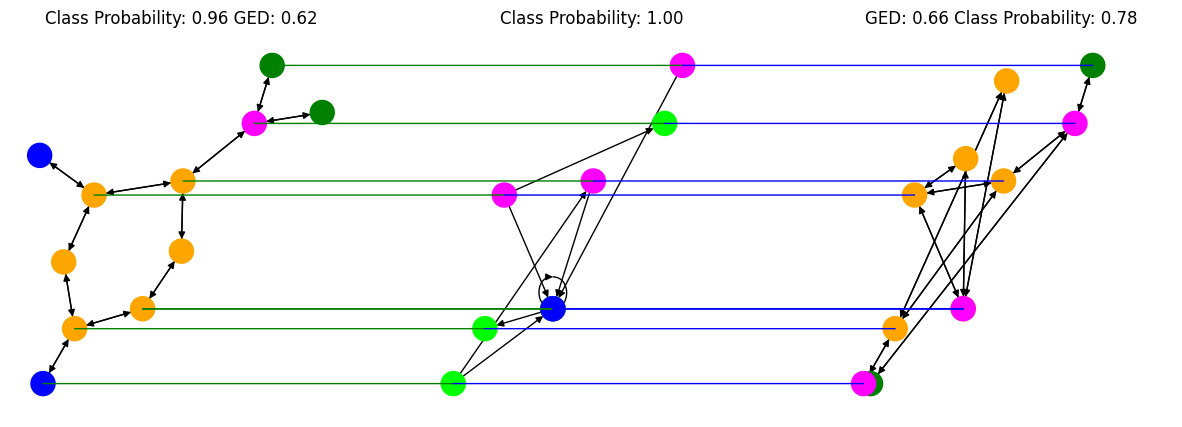

In [37]:
vis_con_graph(
    gen_gnnInt_0_oc,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [38]:
gen_gnnInt_1_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.002474434549349098 SD: 0.004548581928089645
(0.0022, 0.0028)
Baseline % GED to 1
Mean 0.07982263501201357 SD: 0.0013524383978922429
(0.0786, 0.0811)
Baseline % GED to 0
Mean 0.06602750718593597 SD: 0.005657052211688541
(0.0601, 0.072)
Epoch: 0 Losses:[2.3259831125086006, -0.23210407387126575, 11653.734752308239, 2.3754611665552314]
Epoch: 1 Losses:[2.161568056453358, -0.1459779292345047, 1865.3970281427557, 2.261022621935064]
Epoch: 2 Losses:[1.7391373027454724, -0.1830044686794281, 589.6066672585227, 2.2128727327693594]
Epoch: 3 Losses:[1.1987616257234053, -0.4107261869040402, 257.04696377840907, 2.0952891924164514]
Epoch: 4 Losses:[0.9520901170643893, -0.5364697060801766, 124.1313906582919, 2.1762764128771694]
Epoch: 5 Losses:[0.7806753299453042, -0.6825943751768633, 55.62529303810813, 2.136836447499015]
Epoch: 6 Losses:[0.719230749390342, -0.7160115079446272, 25.485986709594727, 2.1286566365848887]
Epoch: 7 Losses:[0.6893968798897483, -0.7452091

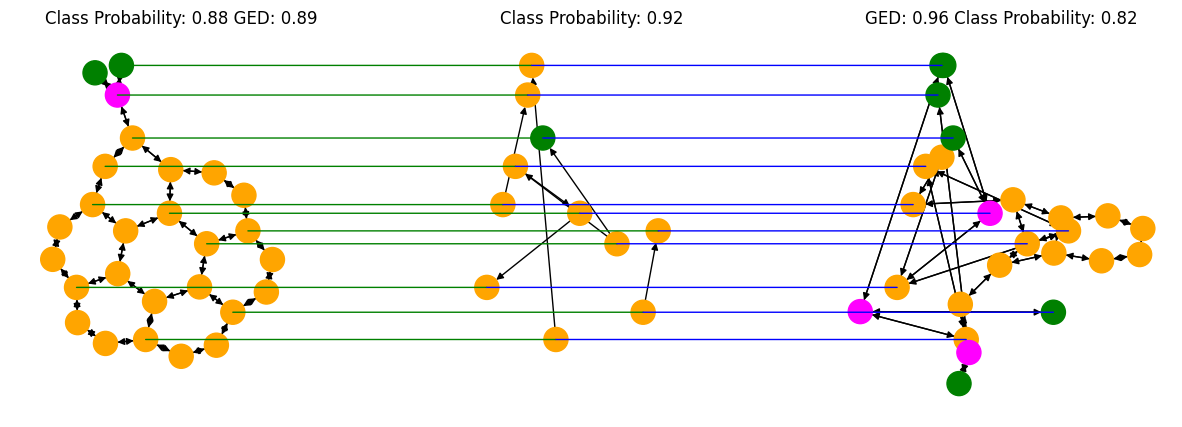

In [39]:
vis_con_graph(
    gen_gnnInt_1_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [40]:
gen_gnnInt_0_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9721497794985772 SD: 0.019963106158276338
(0.9709, 0.9734)
Baseline % GED to 1
Mean 0.08016782440245152 SD: 0.0019575392352391384
(0.0789, 0.0814)
Baseline % GED to 0
Mean 0.06868773698806763 SD: 0.001322268861412879
(0.0654, 0.072)
Epoch: 0 Losses:[0.6275576949119568, -1.1173124421726575, 11737.380260120739, -2.6207045099952]
Epoch: 1 Losses:[0.6452458500862122, -1.141245256770741, 1878.1350929953835, -2.8210403377359565]
Epoch: 2 Losses:[0.6496210477568887, -1.1469606811350042, 568.7229697487571, -2.887686848640442]
Epoch: 3 Losses:[0.6600409583611921, -1.1587338772687046, 206.17496837269175, -2.969848773696206]
Epoch: 4 Losses:[0.6590520197694952, -1.1581955281170933, 84.17499160766602, -2.910888346758756]
Epoch: 5 Losses:[0.6582994569431652, -1.1578767082907937, 36.55091736533425, -3.0027660023082388]
Epoch: 6 Losses:[0.6619324629957025, -1.1612843816930598, 16.577982902526855, -2.9987379854375664]
Epoch: 7 Losses:[0.6663599556142633, -1.165203

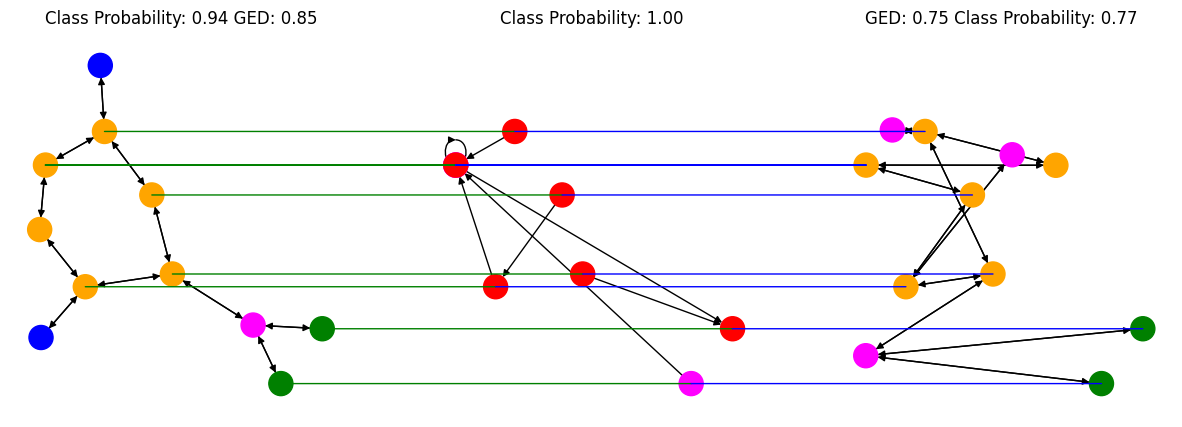

In [41]:
vis_con_graph(
    gen_gnnInt_0_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Only GED

In [42]:
gen_gnnInt_1_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-4, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.03944836263253819 SD: 0.03531751732107981
(0.0373, 0.0416)
Baseline % GED to 1
Mean 0.08476696908473969 SD: 0.0014382687614500238
(0.0834, 0.0861)
Baseline % GED to 0
Mean 0.07207190369566281 SD: 0.004133007590220265
(0.0677, 0.0764)
Epoch: 0 Losses:[2.349361939863725, -0.3673708899454637, 13896.54629794034, 2.4175430915572425]
Epoch: 1 Losses:[2.2189999493685635, -0.30521930889649823, 3030.1628639914775, 2.3407408703457224]
Epoch: 2 Losses:[2.077131076292558, -0.2767044685103677, 1354.7410888671875, 2.0597087524153967]
Epoch: 3 Losses:[1.9022980494932695, -0.2536160512404008, 753.6873224431819, 1.8293658278205178]
Epoch: 4 Losses:[1.8590945330533115, -0.24951454590667377, 527.2135342684659, 1.764583324844187]
Epoch: 5 Losses:[1.6852830106561834, -0.23948143151673404, 370.6968245072798, 1.6455732800743796]
Epoch: 6 Losses:[1.6890071738849988, -0.22713050110773605, 319.2589305530895, 1.5193406560204246]
Epoch: 7 Losses:[1.6018978682431309, -0.236436

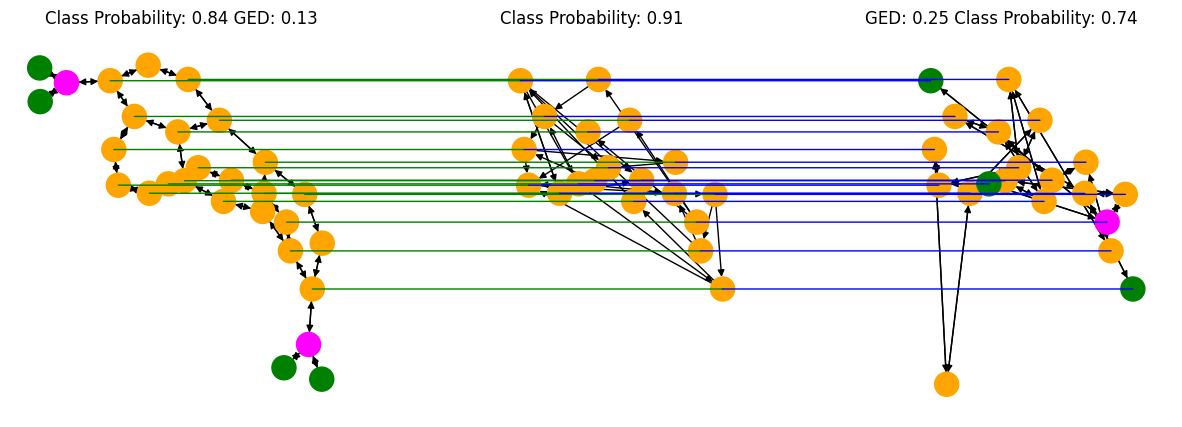

In [43]:
vis_con_graph(
    gen_gnnInt_1_GED, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[3].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [44]:
gen_gnnInt_0_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.8687717189192772 SD: 0.05852885474542409
(0.8651, 0.8724)
Baseline % GED to 1
Mean 0.0842862416590963 SD: 0.0016028422750914246
(0.0828, 0.0858)
Baseline % GED to 0
Mean 0.069078649704655 SD: 0.003108039986644538
(0.0658, 0.0723)
Epoch: 0 Losses:[0.8257957155054266, -1.1309207461097024, 15754.419211647728, -2.7214235825972124]
Epoch: 1 Losses:[0.771087034182115, -1.1595030697909268, 4799.797740589489, -2.8209495544433594]
Epoch: 2 Losses:[0.8401128541339528, -1.1382087685845115, 2367.128240411932, -2.8923866748809814]
Epoch: 3 Losses:[0.8071422685276378, -1.1458538553931497, 1400.315585049716, -2.915839048949155]
Epoch: 4 Losses:[0.8064422119747509, -1.1555943922563032, 896.1153453480114, -2.9363728761672974]
Epoch: 5 Losses:[0.8044477972117338, -1.1545678702267734, 592.6013294566761, -2.8683360815048218]
Epoch: 6 Losses:[0.7619063312357123, -1.1818932728333906, 376.97469815340907, -2.8834068829363044]
Epoch: 7 Losses:[0.810521971095692, -1.1528961

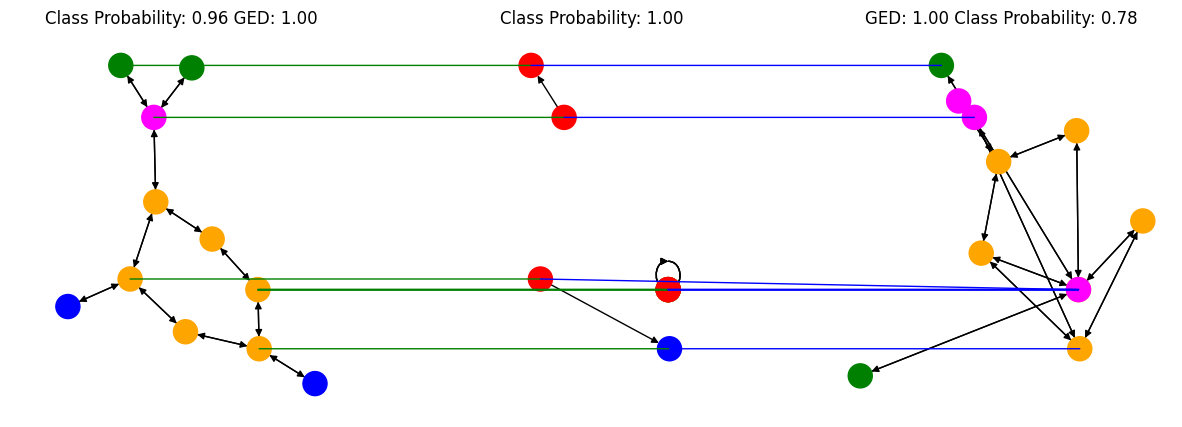

In [45]:
vis_con_graph(
    gen_gnnInt_0_GED,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [46]:
gen_gnnInt_1_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.008944772081129485 SD: 0.009382880967445677
(0.0084, 0.0095)
Baseline % GED to 1
Mean 0.07834646105766296 SD: 0.0012576208521528787
(0.0772, 0.0795)
Baseline % GED to 0
Mean 0.0666050190726916 SD: 0.004447366124798896
(0.0619, 0.0713)
Epoch: 0 Losses:[2.280131058259444, -0.20648459683765064, 17783.549538352272, 1.9583515037189831]
Epoch: 1 Losses:[2.190780748020519, -0.146963279355656, 12512.31747159091, 1.6772271394729614]
Epoch: 2 Losses:[2.120480320670388, -0.11422291262583299, 11798.09659090909, 1.4901451685211875]
Epoch: 3 Losses:[2.0404930764978584, -0.10542418672279878, 11561.972123579546, 1.3141401301730762]
Epoch: 4 Losses:[1.9250934340737083, -0.12442632629112764, 11543.82919034091, 1.2318733415820382]
Epoch: 5 Losses:[1.8217581727287986, -0.1497812975536693, 11645.058416193182, 1.1462424939328975]
Epoch: 6 Losses:[1.7496797279878096, -0.17869507724588568, 11596.799183238636, 1.094916051084345]
Epoch: 7 Losses:[1.536883300000971, -0.26151

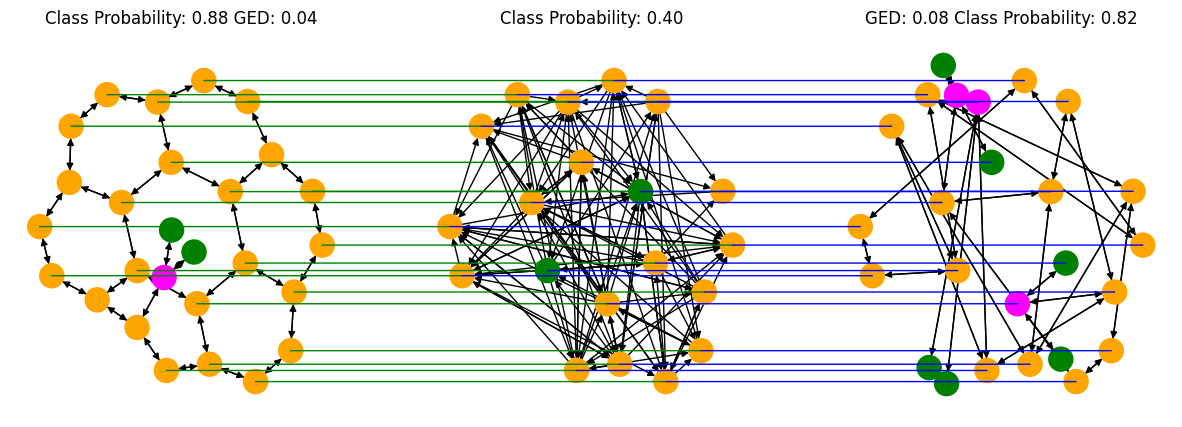

In [47]:
vis_con_graph(
    gen_gnnInt_1_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [48]:
gen_gnnInt_0_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9994099190235138 SD: 0.001559791882454456
(0.9993, 0.9995)
Baseline % GED to 1
Mean 0.08469887139896552 SD: 0.002206735924432056
(0.0833, 0.0861)
Baseline % GED to 0
Mean 0.06963406503200531 SD: 0.001766231847789785
(0.0652, 0.074)
Epoch: 0 Losses:[0.6603211868893016, -1.1555527665398337, 13536.918190696022, -2.6966618462042375]
Epoch: 1 Losses:[0.6799975741993297, -1.1759700775146484, 3666.5543323863635, -2.932583061131564]
Epoch: 2 Losses:[0.6914488022977655, -1.1869576194069602, 1746.2790194424715, -2.9455126849087803]
Epoch: 3 Losses:[0.6917364705692638, -1.1852563186125322, 889.0613236860795, -3.04716816815463]
Epoch: 4 Losses:[0.6986924734982577, -1.1919880780306729, 482.47772216796875, -3.035119132562117]
Epoch: 5 Losses:[0.7004826990040866, -1.1932580471038818, 260.813495982777, -3.045987140048634]
Epoch: 6 Losses:[0.7057933428070762, -1.196843764998696, 133.6964201493697, -3.132397478277033]
Epoch: 7 Losses:[0.7073719013820995, -1.19800989

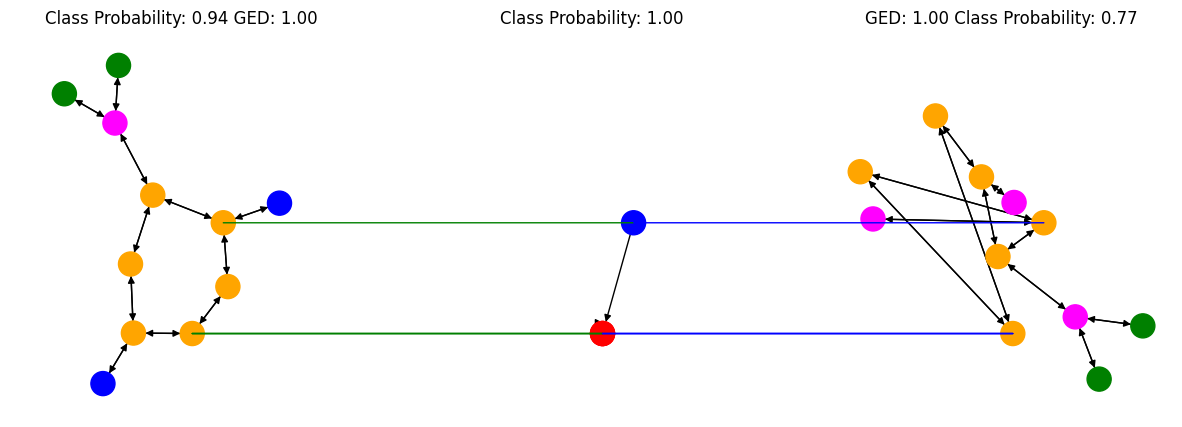

In [49]:
vis_con_graph(
    gen_gnnInt_0_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Full Loss

In [55]:
gen_gnnInt_1_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-4, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.021422080923439352 SD: 0.02543613467659635
(0.0198, 0.023)
Baseline % GED to 1
Mean 0.09180930043969836 SD: 0.003278412939651947
(0.0888, 0.0948)
Baseline % GED to 0
Mean 0.07426824669043224 SD: 0.005016168694323312
(0.069, 0.0795)
Epoch: 0 Losses:[1.9938221953131936, -0.43799186565659265, 13141.68710049716, 2.475878818468614]
Epoch: 1 Losses:[1.3899042714725842, -0.6022640845992349, 4001.411044034091, 2.3249615159901706]
Epoch: 2 Losses:[0.9218348264694214, -0.8258135372942145, 2111.8469016335225, 2.191693652759899]
Epoch: 3 Losses:[0.8814092549410734, -0.8690607114271685, 1088.4679953835227, 2.0766396712173116]
Epoch: 4 Losses:[0.8092025193301114, -0.9048493558710272, 614.8067099831321, 1.9873341809619556]
Epoch: 5 Losses:[0.7244958877563477, -0.9464091441848062, 424.968222878196, 1.8516088832508435]
Epoch: 6 Losses:[0.7155827663161538, -0.9263391115448691, 309.7968084161932, 1.7322468649257312]
Epoch: 7 Losses:[0.7304468805139716, -0.91157110170

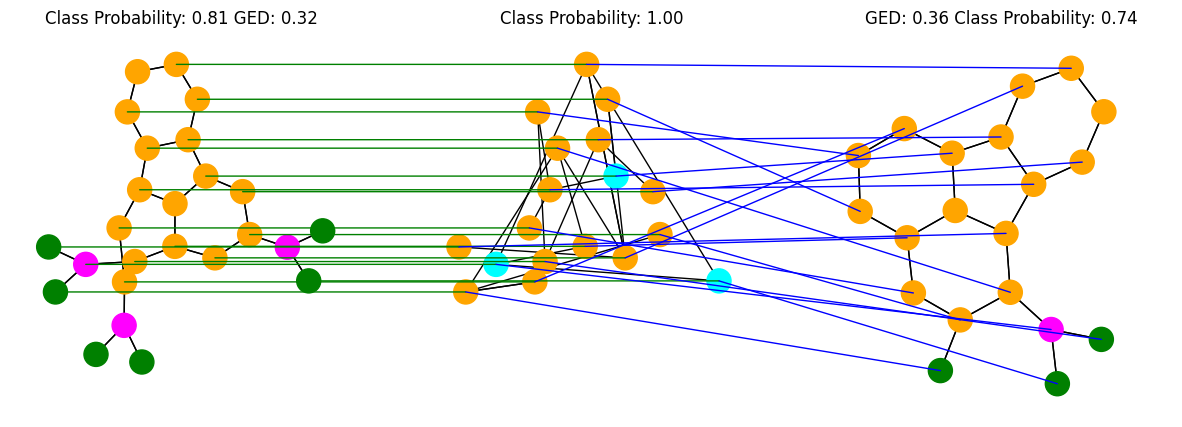

In [130]:
vis_con_graph(
    gen_gnnInt_1_full, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

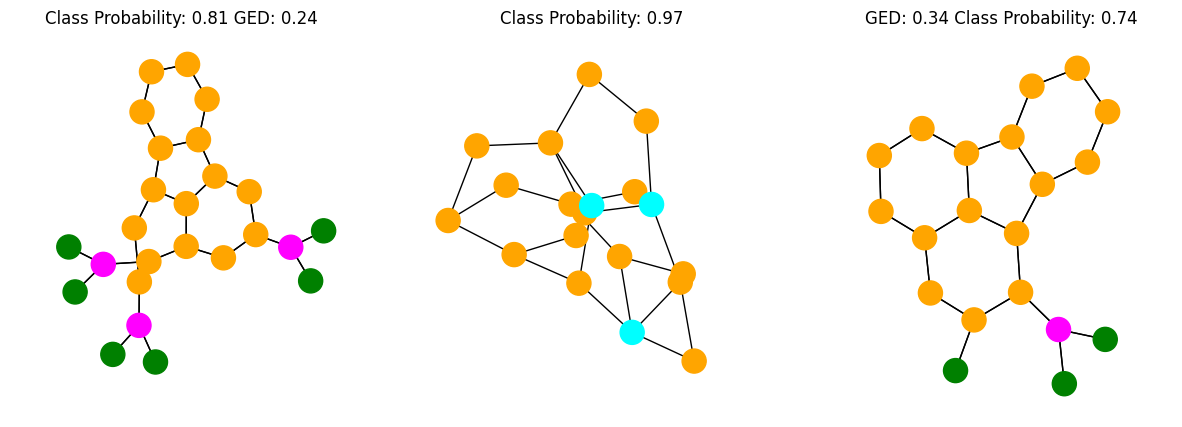

In [126]:
vis_con_graph_replace(
    gen_gnnInt_1_full, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [97]:
gen_gnnInt_0_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1e5]), 
)

Baseline Prediction Accuracy: 
Mean 0.8718529968857766 SD: 0.06201020198801561
(0.868, 0.8757)
Baseline % GED to 1
Mean 0.08504314188446317 SD: 0.002407049314988431
(0.0828, 0.0873)
Baseline % GED to 0
Mean 0.06893163298567136 SD: 0.003999749013092495
(0.0647, 0.0731)
Epoch: 0 Losses:[0.8183638616041704, -1.0277403647249395, 24262.84552556818, -2.6609955592588945]
Epoch: 1 Losses:[0.902843713760376, -1.0283325422893872, 14461.361061789772, -2.7947770140387793]
Epoch: 2 Losses:[0.8210487419908697, -1.088708146051927, 10261.61221590909, -2.9491806247017602]
Epoch: 3 Losses:[0.8713995651765303, -1.0583264827728271, 7638.244495738636, -2.8856520761143076]
Epoch: 4 Losses:[0.9561402580954812, -1.0129191929643804, 5852.517844460227, -2.87658889727159]
Epoch: 5 Losses:[0.9181718880479987, -1.0449240641160444, 4503.505925958807, -2.915672020478682]
Epoch: 6 Losses:[0.8634379018436779, -1.0806755044243552, 3508.9932972301135, -2.9357996962287207]
Epoch: 7 Losses:[0.8847441239790483, -1.07823267

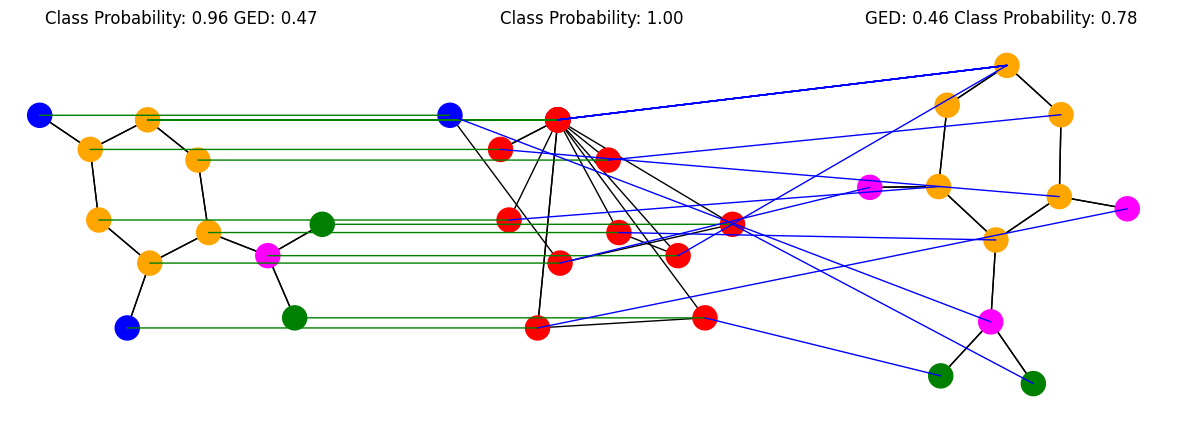

In [98]:
vis_con_graph(
    gen_gnnInt_0_full,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

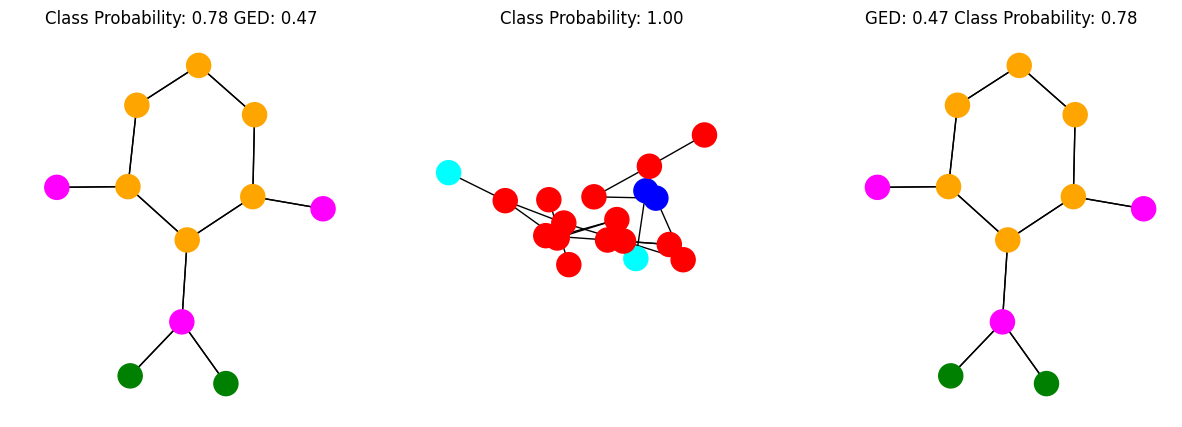

In [102]:
vis_con_graph_replace(
    gen_gnnInt_0_full,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[4].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [54]:
gen_gnnInt_1_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
    epochs=25
)

Baseline Prediction Accuracy: 
Mean 0.003414441592318326 SD: 0.0048299489681929665
(0.0031, 0.0037)
Baseline % GED to 1
Mean 0.07463260207857404 SD: 0.0019983195640475636
(0.0728, 0.0765)
Baseline % GED to 0
Mean 0.061061080545186996 SD: 0.003600067022198824
(0.0573, 0.0648)
Epoch: 0 Losses:[2.3485931049693716, -0.25886022638190875, 22720.936257102272, 2.069025153463537]
Epoch: 1 Losses:[2.2826587070118296, -0.21224864504554056, 14260.278941761364, 1.793272609060461]
Epoch: 2 Losses:[2.1829466819763184, -0.14835648848251862, 12943.14559659091, 1.5558256723664023]
Epoch: 3 Losses:[2.097103010524403, -0.11744970218701796, 12467.257279829546, 1.4291073083877563]
Epoch: 4 Losses:[1.99017042463476, -0.10403294251723723, 12263.803000710228, 1.3589759360660205]
Epoch: 5 Losses:[1.778012676672502, -0.16523287106644025, 12002.07120028409, 1.1836971586400813]
Epoch: 6 Losses:[1.5026411468332463, -0.26474024084481323, 12055.825461647728, 1.101646071130579]
Epoch: 7 Losses:[1.239302017472007, -0.3

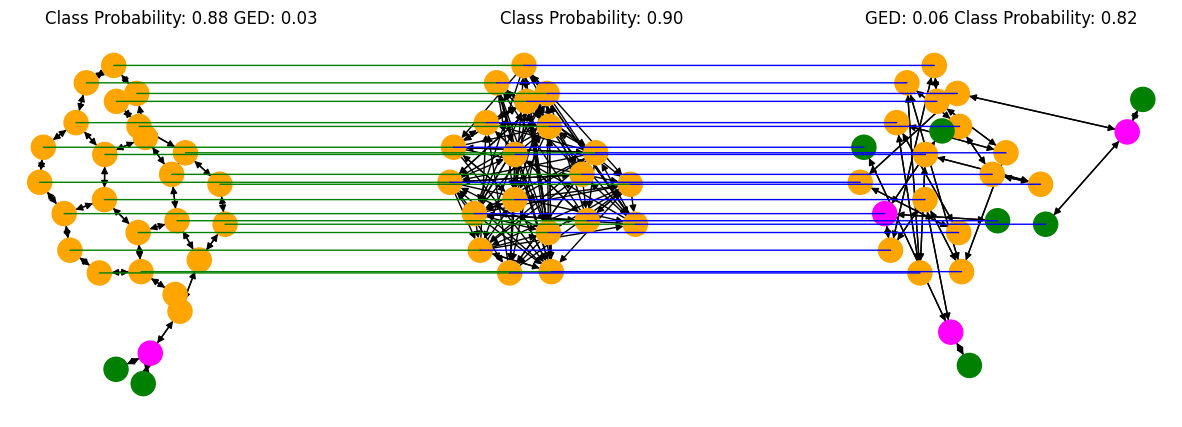

In [55]:
vis_con_graph(
    gen_gnnInt_1_dropped_full, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [56]:
gen_gnnInt_0_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
Mean 0.9905395220518112 SD: 0.010285602102847761
(0.9899, 0.9912)
Baseline % GED to 1
Mean 0.08152739889919758 SD: 0.003223359274913004
(0.0795, 0.0836)
Baseline % GED to 0
Mean 0.06797496974468231 SD: 0.00032777337201860283
(0.0672, 0.0688)
Epoch: 0 Losses:[0.6313303058797662, -1.1278061324899846, 14466.0400390625, -2.6747908646410163]
Epoch: 1 Losses:[0.6503476933999495, -1.1480777155269275, 4385.630193536932, -2.935239000753923]
Epoch: 2 Losses:[0.6618053371256049, -1.1596377762881191, 2206.0788907137785, -2.9394227916544136]
Epoch: 3 Losses:[0.6682139906016263, -1.1657592925158413, 1330.9094127308238, -2.9980225563049316]
Epoch: 4 Losses:[0.6661762270060453, -1.1639393676411023, 880.9117764559659, -3.051699540831826]
Epoch: 5 Losses:[0.6749606349251487, -1.17210345918482, 529.0101540305398, -3.0763514908877285]
Epoch: 6 Losses:[0.6755805936726657, -1.1730539473620327, 300.253193248402, -2.9945718375119297]
Epoch: 7 Losses:[0.6794845190915194, -1.17617

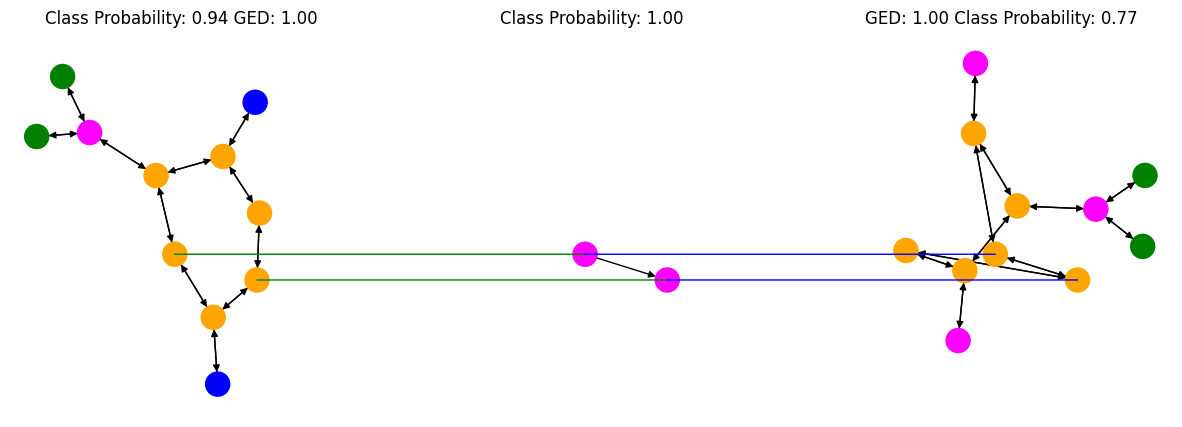

In [57]:
vis_con_graph(
    gen_gnnInt_0_dropped_full, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Parameter Distribution

In [58]:
data_0 = train_data_list_0 + test_data_list_0
data_1 = train_data_list_1 + test_data_list_1

batch_0 = pyg.data.Batch.from_data_list(data_0)
batch_1 = pyg.data.Batch.from_data_list(data_1)

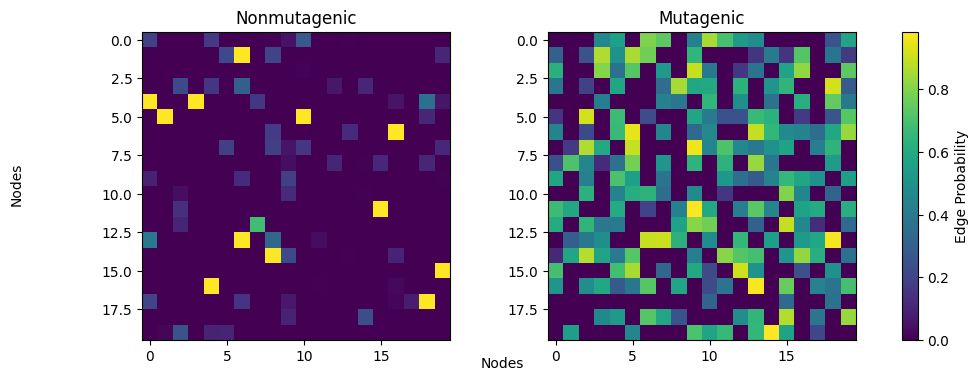

In [59]:
edge_probs_0 = gen_gnnInt_0_full.AdjacencyMatrix.probs
edge_probs_0 = edge_probs_0.detach().cpu().numpy()

edge_probs_1 = gen_gnnInt_1_full.AdjacencyMatrix.probs
edge_probs_1 = edge_probs_1.detach().cpu().numpy()

# edge_probs_untrained = generator_untrained.AdjacencyMatrix.probs
# edge_probs_untrained = edge_probs_untrained.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(edge_probs_0, cmap='viridis', interpolation='nearest')
im1 = axes[1].imshow(edge_probs_1, cmap='viridis', interpolation='nearest')
#im2 = axes[2].imshow(edge_probs_untrained, cmap='viridis', interpolation='nearest')

# Add a common color bar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label('Edge Probability')

# Set titles
axes[0].set_title('Nonmutagenic')
axes[1].set_title('Mutagenic')
# axes[2].set_title('Untrained')

# Set common x and y labels
fig.text(0.45, 0.04, 'Nodes', ha='center')
fig.text(0.04, 0.5, 'Nodes', va='center', rotation='vertical')

plt.show()

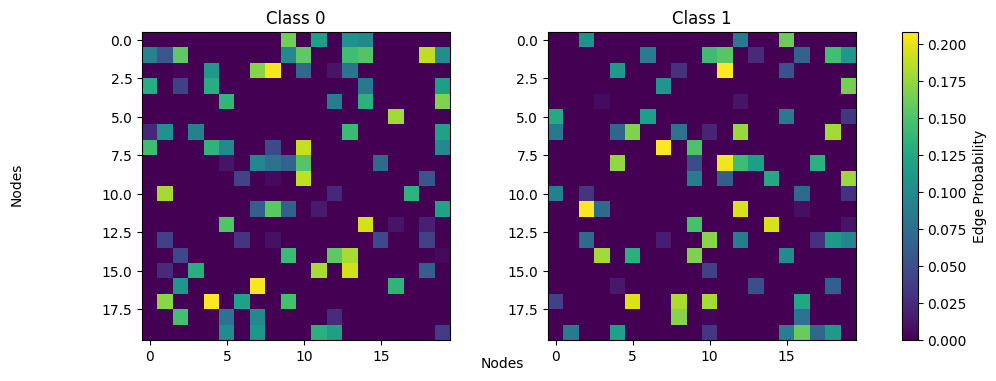

In [60]:
edge_probs_0 = gen_gnnInt_0_oc.AdjacencyMatrix.probs
edge_probs_0 = edge_probs_0.detach().cpu().numpy()

edge_probs_1 = gen_gnnInt_1_oc.AdjacencyMatrix.probs
edge_probs_1 = edge_probs_1.detach().cpu().numpy()

# edge_probs_untrained = generator_untrained.AdjacencyMatrix.probs
# edge_probs_untrained = edge_probs_untrained.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(edge_probs_0, cmap='viridis', interpolation='nearest')
im1 = axes[1].imshow(edge_probs_1, cmap='viridis', interpolation='nearest')
#im2 = axes[2].imshow(edge_probs_untrained, cmap='viridis', interpolation='nearest')

# Add a common color bar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label('Edge Probability')

# Set titles
axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
# axes[2].set_title('Untrained')

# Set common x and y labels
fig.text(0.45, 0.04, 'Nodes', ha='center')
fig.text(0.04, 0.5, 'Nodes', va='center', rotation='vertical')

plt.show()

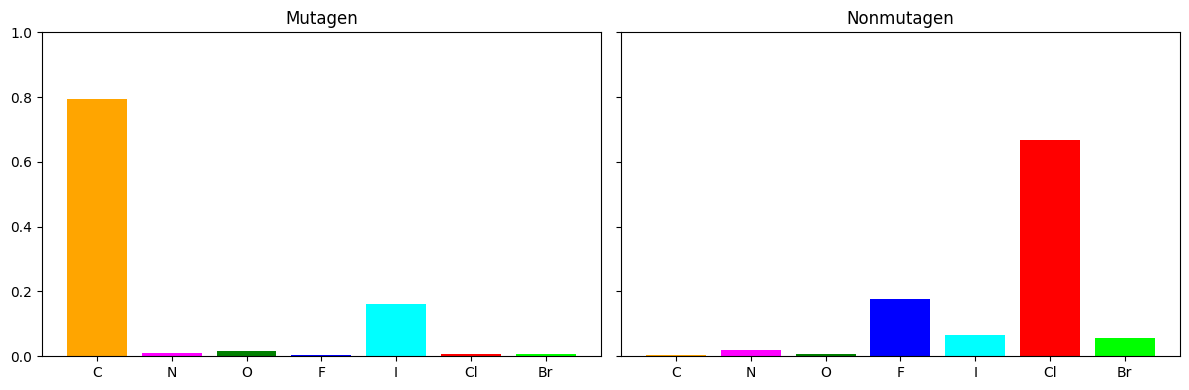

In [94]:
cell_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_0 = cell_type_probs_0.detach().cpu().numpy()

cell_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_1 = cell_type_probs_1.detach().cpu().numpy()

# cell_type_probs_untrained = torch.softmax(
#     generator_untrained.DisNodeFeats[0].probs, dim=0)
# cell_type_probs_untrained = cell_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[1].bar(plot_indices, cell_type_probs_0, color=color_palette)
axes[0].bar(plot_indices, cell_type_probs_1, color=color_palette)
#axes[2].bar(plot_indices, cell_type_probs_untrained, color=color_palette)

axes[1].set_title('Nonmutagen')
axes[0].set_title('Mutagen')
#axes[2].set_title('Untrained')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

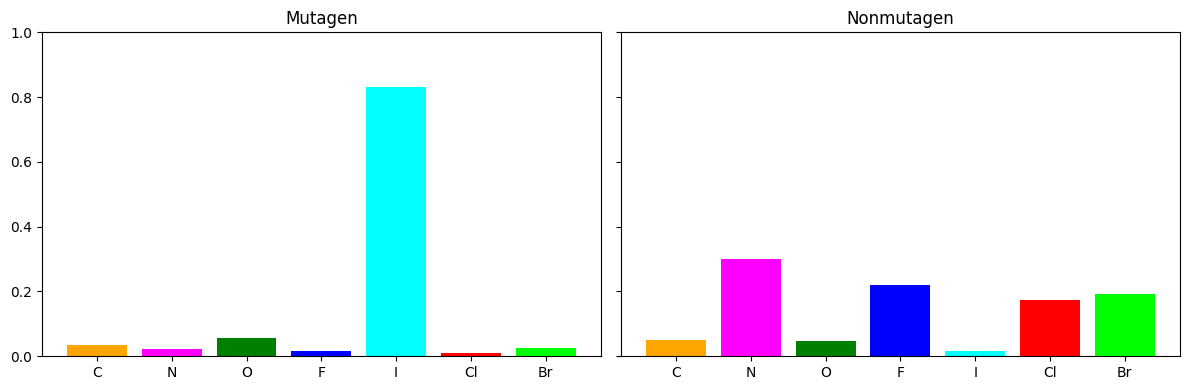

In [93]:
cell_type_probs_0 = torch.softmax(gen_gnnInt_0_oc.DisNodeFeats[0].probs, dim=0)
cell_type_probs_0 = cell_type_probs_0.detach().cpu().numpy()

cell_type_probs_1 = torch.softmax(gen_gnnInt_1_oc.DisNodeFeats[0].probs, dim=0)
cell_type_probs_1 = cell_type_probs_1.detach().cpu().numpy()

# cell_type_probs_untrained = torch.softmax(
#     generator_untrained.DisNodeFeats[0].probs, dim=0)
# cell_type_probs_untrained = cell_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[1].bar(plot_indices, cell_type_probs_0, color=color_palette)
axes[0].bar(plot_indices, cell_type_probs_1, color=color_palette)
#axes[2].bar(plot_indices, cell_type_probs_untrained, color=color_palette)

axes[1].set_title('Nonmutagen')
axes[0].set_title('Mutagen')
#axes[2].set_title('Untrained')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

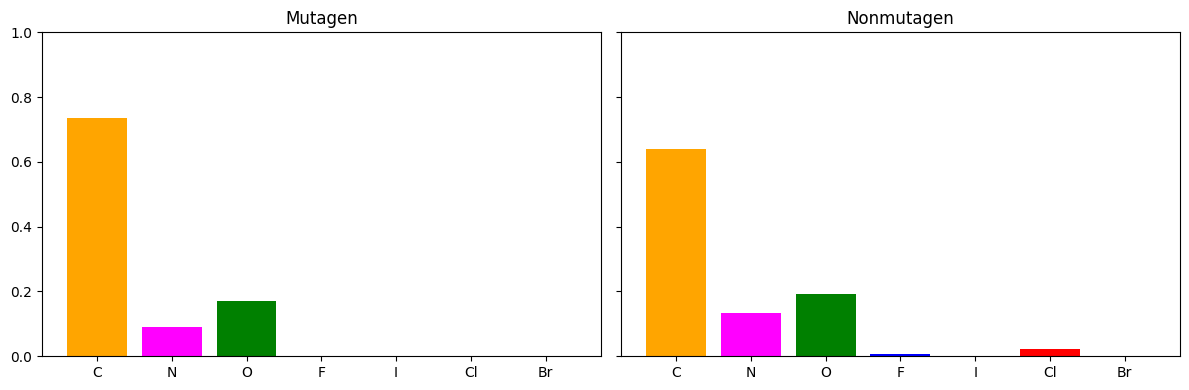

In [92]:
emp_dist_node_0 = batch_0.x.argmax(dim=-1).numpy()
emp_dist_node_1 = batch_1.x.argmax(dim=-1).numpy()

# Empirical node type probabilities
unique_classes_0, counts_0 = np.unique(emp_dist_node_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_node_0))
percentages_0 = np.insert(percentages_0, 4, 0.0) # missing I

unique_classes_1, counts_1 = np.unique(emp_dist_node_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_node_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']

axes[1].bar(plot_indices, percentages_0, color=color_palette)
axes[0].bar(plot_indices, percentages_1, color=color_palette)

axes[1].set_title('Nonmutagen')
axes[0].set_title('Mutagen')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

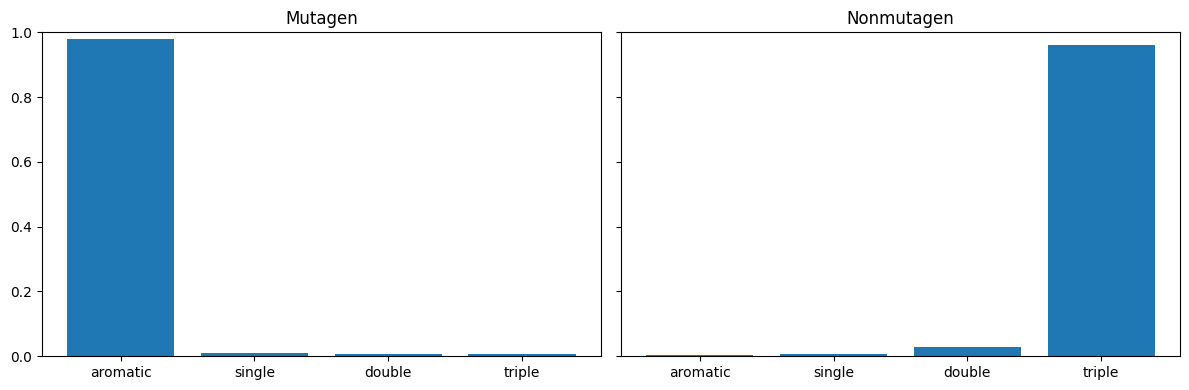

In [91]:
edge_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_0 = edge_type_probs_0.detach().cpu().numpy()

edge_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_1 = edge_type_probs_1.detach().cpu().numpy()

# edge_type_probs_untrained = torch.softmax(
#     generator_untrained.DisEdgeFeats[0].probs, dim=0)
# edge_type_probs_untrained = edge_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[1].bar(plot_indices, edge_type_probs_0)
axes[0].bar(plot_indices, edge_type_probs_1)
#axes[2].bar(plot_indices, edge_type_probs_untrained)

axes[1].set_title('Nonmutagen')
axes[0].set_title('Mutagen')
#axes[2].set_title('Untrained')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

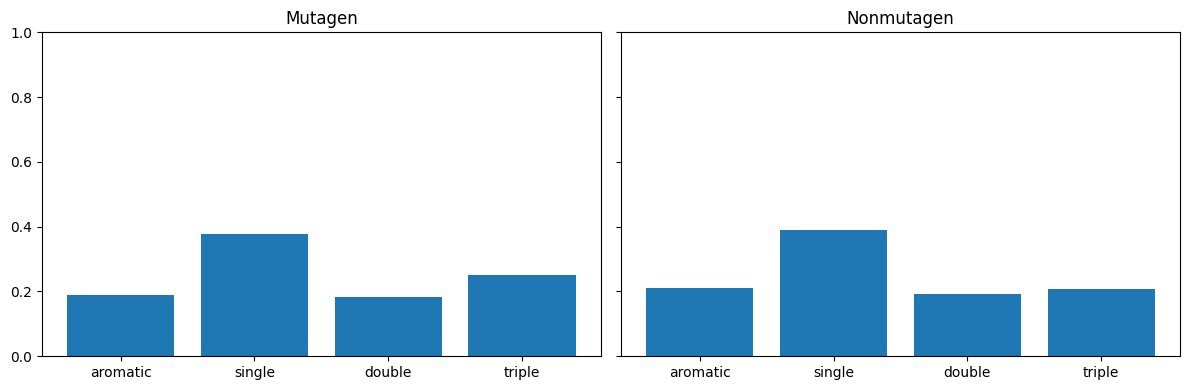

In [90]:
edge_type_probs_0 = torch.softmax(gen_gnnInt_0_oc.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_0 = edge_type_probs_0.detach().cpu().numpy()

edge_type_probs_1 = torch.softmax(gen_gnnInt_1_oc.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_1 = edge_type_probs_1.detach().cpu().numpy()

# edge_type_probs_untrained = torch.softmax(
#     generator_untrained.DisEdgeFeats[0].probs, dim=0)
# edge_type_probs_untrained = edge_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[1].bar(plot_indices, edge_type_probs_0)
axes[0].bar(plot_indices, edge_type_probs_1)
#axes[2].bar(plot_indices, edge_type_probs_untrained)

axes[1].set_title('Nonmutagen')
axes[0].set_title('Mutagen')
#axes[2].set_title('Untrained')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

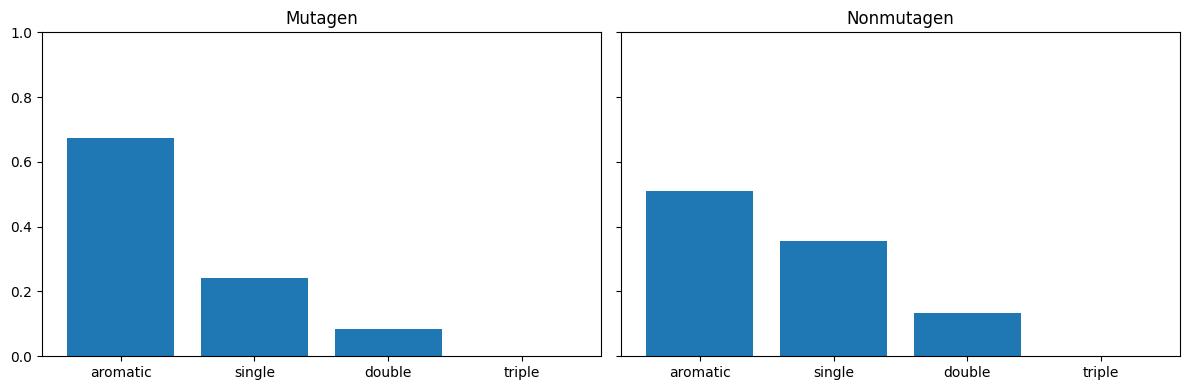

In [89]:
# Empirical edge type probabilities
emp_dist_edge_0 = batch_0.edge_attr.argmax(dim=-1).numpy()
emp_dist_edge_1 = batch_1.edge_attr.argmax(dim=-1).numpy()

unique_classes_0, counts_0 = np.unique(emp_dist_edge_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_edge_0))
percentages_0 = np.insert(percentages_0, 3, 0.0) # no triples. 

unique_classes_1, counts_1 = np.unique(emp_dist_edge_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_edge_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[1].bar(edge_types, percentages_0)
axes[0].bar(edge_types, percentages_1)

axes[1].set_title('Nonmutagen')
axes[0].set_title('Mutagen')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Clean-UP

In [89]:
import gc

# Get all objects in the current context
for obj in gc.get_objects():
    if torch.is_tensor(obj) and obj.is_cuda:
        del obj

# Clear the cache
torch.cuda.empty_cache()

# Optionally synchronize (wait for GPU computations to finish)
torch.cuda.synchronize()

/opt/miniconda/envs/egg-env-38/lib/python3.10/site-packages/torch/__init__.py:836: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)
